# The thermal environment: when one temperature is not enough

In a shielded laboratory enclosure, PTB's cooled copper shield or NIST
Yb's carbon-nanotube-coated interior, the surfaces an atom's clock
transition actually sees sit within a fraction of a kelvin of one
another. A single temperature characterizes the resulting blackbody
radiation shift completely in that setting. A clock deployed in the
field has no such enclosure. It might ride in a vehicle, or sit behind
a viewport that a diurnal cycle or a nearby heat source can warm
relative to the surrounding chamber. This notebook shows directly that
representing a tens-of-kelvin spread across its surfaces by any single
effective temperature fails at the accuracy modern clocks now reach.

The mismatch between the exact multi-surface shift and the best
single-temperature approximation crosses `1e-18`, close to a modern
lattice clock's total systematic budget. That crossing happens at
roughly an 11 K spread for two surfaces split evenly, and at roughly
19 K for a small warm viewport against a larger chamber body. Both
crossings are computed live in the sweep below.

That failure is real for a field unit. The tool this notebook
exercises responds to it directly: it takes each surface's own
temperature and sensor uncertainty as input, and returns the BBR
correction together with a defensible error band. The chamber diagram,
all three validation anchors, and the field-sensitivity scenario below
all exercise that same path end to end.

The same per-surface engine also takes a lab's own published
ray-traced exchange factors as input. A real chamber's Table 2.7,
alongside its 22 C viewport setpoint, reduces exactly to a single
effective temperature. That reduction holds because that lab controls
its environment well enough for one to hold. The same weights, swept across sample
position, reproduce a real measured position-resolved shift and can
feed a gradient line item into a millimeter-scale redshift
measurement's own error budget.

In [1]:
%matplotlib inline
import math
import time

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from cliffordclock.ensemble.species import get_species
from cliffordclock.integrator.omega import (
    RadiationSurface,
    _bbr_effective_weights,
    bbr_environment_effective_temperatures,
    bbr_environment_pivot_perturbation,
    bbr_environment_pivot_uncertainty,
    bbr_pivot_perturbation,
)

_notebook_start_s = time.time()
np.set_printoptions(precision=6, suppress=False)
sr87 = get_species("Sr87")
print(f"species: Sr87, clock frequency nu_0 = {sr87.clock_frequency_hz:.6f} Hz")

species: Sr87, clock frequency nu_0 = 429228004229873.375000 Hz


## 1. The chamber you are modeling: surfaces, weights, temperatures

The figure below is what `bbr_environment_pivot_perturbation` consumes
for the field-deployment scenario this notebook returns to in its
validation and sensitivity sections: a small set of named surfaces,
each carrying a solid-angle weight, a temperature, and a sensor
uncertainty. Wedge angle encodes each surface's weight and wedge color
encodes its temperature on the colorbar at right. The diagram reads
its numbers directly from the `SCENARIO_SURFACES` tuple every
computation below also calls, so it cannot drift from the model it
depicts.

In [2]:
SCENARIO_SURFACES = (
    RadiationSurface(
        name="chamber",
        weight=0.87,
        temperature_k=296.0,
        temperature_uncertainty_k=0.5,
    ),
    RadiationSurface(
        name="hot_window",
        weight=0.08,
        temperature_k=320.0,
        temperature_uncertainty_k=1.0,
    ),
    RadiationSurface(
        name="cold_window",
        weight=0.05,
        temperature_k=285.0,
        temperature_uncertainty_k=2.0,
    ),
)

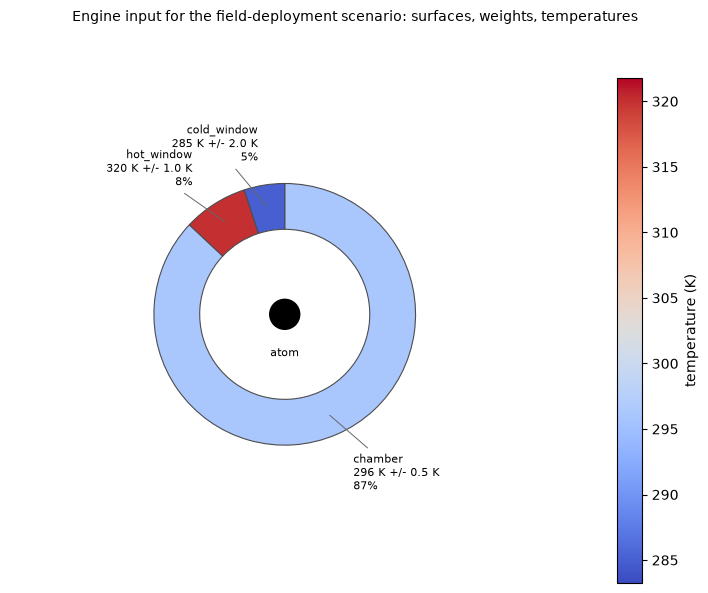

In [3]:
def chamber_schematic(ax, surfaces, cmap_name="coolwarm", start_deg=90.0, side_list_below=0.0):
    """Cross-section schematic: atom at center, one wedge per surface, each
    wedge's angular extent its `weight` fraction of 360 deg and its color
    mapped to its `temperature_k`. Reads directly from `surfaces`
    (RadiationSurface instances), so the figure cannot drift from what the
    computations below actually consume.

    `side_list_below`: surfaces with `weight` under this fraction get a
    numbered leader tick instead of an inline label, with the name,
    temperature, and weight moved to a numbered list below the wedge; several
    thin wedges packed close together (Table 2.7's smallest rows) would
    otherwise print overlapping inline labels no reader could separate.
    Default `0.0` never triggers this (every surface keeps its inline label),
    the original behavior.
    """
    temps = [s.temperature_k for s in surfaces]
    t_lo, t_hi = min(temps), max(temps)
    pad = max(1.0, 0.05 * (t_hi - t_lo))
    norm = mcolors.Normalize(vmin=t_lo - pad, vmax=t_hi + pad)
    cmap = plt.get_cmap(cmap_name)
    theta = start_deg
    small_surfaces = []
    small_index = 0
    last_small_deg = None
    fan = 0
    for surface in surfaces:
        span = surface.weight * 360.0
        color = cmap(norm(surface.temperature_k))
        wedge = mpatches.Wedge(
            (0, 0),
            1.0,
            theta - span,
            theta,
            width=0.35,
            facecolor=color,
            edgecolor="0.3",
            linewidth=0.8,
        )
        ax.add_patch(wedge)
        mid_deg = theta - span / 2.0
        mid = math.radians(mid_deg)
        if surface.weight < side_list_below:
            small_index += 1
            small_surfaces.append((small_index, surface))
            # Consecutive thin wedges land at nearly the same angle; fan their
            # tick length out so the numbered labels themselves never touch.
            fan = (
                fan + 1
                if last_small_deg is not None and abs(mid_deg - last_small_deg) < 10.0
                else 0
            )
            last_small_deg = mid_deg
            tick_r1 = 1.10 + 0.13 * fan
            ax.plot(
                [1.0 * math.cos(mid), tick_r1 * math.cos(mid)],
                [1.0 * math.sin(mid), tick_r1 * math.sin(mid)],
                color="0.3",
                lw=0.8,
            )
            ax.annotate(
                str(small_index),
                xy=((tick_r1 + 0.07) * math.cos(mid), (tick_r1 + 0.07) * math.sin(mid)),
                ha="center",
                va="center",
                fontsize=7,
                fontweight="bold",
            )
        else:
            label_r = 1.32
            lx, ly = label_r * math.cos(mid), label_r * math.sin(mid)
            ha = "left" if lx >= -0.05 else "right"
            label = (
                f"{surface.name}\n{surface.temperature_k:.0f} K "
                f"+/- {surface.temperature_uncertainty_k:.1f} K\n"
                f"{surface.weight * 100:.0f}%"
            )
            ax.annotate(
                label,
                xy=(0.825 * math.cos(mid), 0.825 * math.sin(mid)),
                xytext=(lx, ly),
                ha=ha,
                va="center",
                fontsize=8,
                arrowprops=dict(arrowstyle="-", color="0.4", lw=0.7),
            )
        theta -= span
    ax.add_patch(mpatches.Circle((0, 0), 0.12, facecolor="black", zorder=5))
    ax.annotate("atom", xy=(0, 0), xytext=(0, -0.32), ha="center", fontsize=8)
    if small_surfaces:
        lines = ["small-weight surfaces:"]
        for idx, s in small_surfaces:
            lines.append(
                f"{idx}. {s.name.replace('_', ' ')}: {s.temperature_k:.0f} K "
                f"+/- {s.temperature_uncertainty_k:.1f} K, {s.weight * 100:.2f}%"
            )
        ax.text(-2.0, -1.15, "\n".join(lines), ha="left", va="top", fontsize=7, linespacing=1.6)
    ax.set_xlim(-2.1, 2.1)
    ax.set_ylim(-2.0, 1.75)
    ax.set_aspect("equal")
    ax.axis("off")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.09)
    cbar.set_label("temperature (K)")


fig, ax = plt.subplots(figsize=(7.2, 6.0))
chamber_schematic(ax, SCENARIO_SURFACES)
fig.suptitle(
    "Engine input for the field-deployment scenario: surfaces, weights, temperatures",
    fontsize=10,
    y=0.98,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## 2. When one temperature fails

E37 (`docs/CONVENTIONS.md` section 13, gated at G10) is the engine
feature this notebook exercises throughout: It replaces a single
temperature with an explicit multi-surface description and evaluates
both BBR terms against the environment's own per-moment sums. The
mismatch a single effective temperature makes therefore becomes a
number this section computes and prints directly. E32's single temperature is always
the `<T^4>`-matched effective temperature of whatever real environment
it stands in for: for a set of surfaces at solid-angle fractions `w_i`
and temperatures `T_i`, choosing `T_eff = (sum_i w_i T_i^4)^(1/4)`
reproduces the static term exactly by construction. The dynamic term
enjoys no such guarantee, because `sum_i w_i T_i^n` for `n = 6, 8, 10`
is generally not equal to `T_eff^n`.

The cells below sweep the temperature spread between two surfaces for
two geometries, a 50/50 split (two walls of comparable size) and a
10/90 split (one small viewport against a large chamber body). They
evaluate the exact E37 shift and the `T^4`-matched single-temperature
E32 approximation at every spread. They then report where their
difference crosses two thresholds that matter for clock accuracy:
`1e-18`, close to a modern lattice clock's total systematic budget,
and `1e-17`, an order of magnitude above it.

In [4]:
def single_t_mismatch(f, spread_k, species, center_k=300.0):
    """|exact E37 shift - T^4-matched single-T E32 shift| for a two-surface
    environment: fraction f at (center - spread/2), fraction (1-f) at
    (center + spread/2)."""
    t1 = center_k - spread_k / 2.0
    t2 = center_k + spread_k / 2.0
    surfaces = (
        RadiationSurface(name="t1", weight=f, temperature_k=t1),
        RadiationSurface(name="t2", weight=1.0 - f, temperature_k=t2),
    )
    exact = bbr_environment_pivot_perturbation(surfaces, species)
    t_eff_static = (f * t1**4 + (1.0 - f) * t2**4) ** 0.25
    approx = bbr_pivot_perturbation(t_eff_static, species)
    return abs(exact - approx)


def find_crossings(f, thresholds, species, spreads_k):
    mismatches = np.array([single_t_mismatch(f, s, species) for s in spreads_k])
    crossings = {}
    for thresh in thresholds:
        idx = np.searchsorted(mismatches, thresh)
        if 0 < idx < len(spreads_k):
            s0, s1 = spreads_k[idx - 1], spreads_k[idx]
            v0, v1 = mismatches[idx - 1], mismatches[idx]
            crossings[thresh] = s0 + (thresh - v0) * (s1 - s0) / (v1 - v0)
        else:
            crossings[thresh] = None
    return mismatches, crossings


SPREADS_K = np.linspace(0.1, 100.0, 4000)
THRESHOLDS = (1e-18, 1e-17)
SCENARIOS = {"50/50 split": 0.5, "10/90 split (viewport vs. chamber)": 0.1}

sweep_results = {}
for label, f in SCENARIOS.items():
    mismatches, crossings = find_crossings(f, THRESHOLDS, sr87, SPREADS_K)
    sweep_results[label] = (f, mismatches, crossings)
    print(f"{label} (f = {f}):")
    for thresh, spread in crossings.items():
        if spread is not None:
            print(f"  crosses {thresh:.0e} at a spread of {spread:.2f} K")
        else:
            print(f"  does not cross {thresh:.0e} within the scanned range")
    print()

50/50 split (f = 0.5):
  crosses 1e-18 at a spread of 11.13 K
  crosses 1e-17 at a spread of 35.12 K

10/90 split (viewport vs. chamber) (f = 0.1):
  crosses 1e-18 at a spread of 18.60 K
  crosses 1e-17 at a spread of 58.84 K



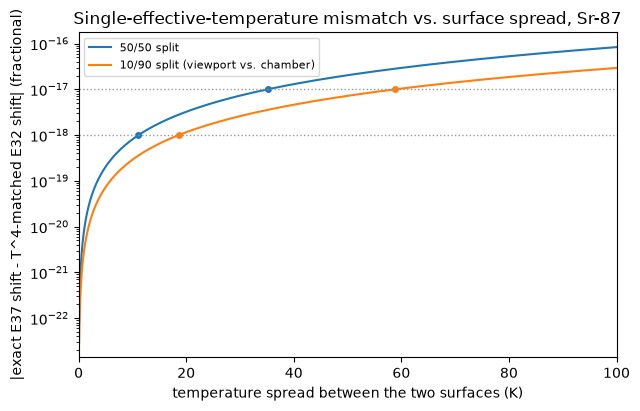

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
colors = {"50/50 split": "C0", "10/90 split (viewport vs. chamber)": "C1"}
for label, (f, mismatches, crossings) in sweep_results.items():
    ax.plot(SPREADS_K, mismatches, color=colors[label], label=label)
    for spread in crossings.values():
        if spread is not None:
            ax.plot(
                spread,
                single_t_mismatch(f, spread, sr87),
                "o",
                color=colors[label],
                markersize=4,
            )
for thresh in THRESHOLDS:
    ax.axhline(thresh, color="0.6", linestyle=":", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("temperature spread between the two surfaces (K)")
ax.set_ylabel("|exact E37 shift - T^4-matched E32 shift| (fractional)")
ax.set_title("Single-effective-temperature mismatch vs. surface spread, Sr-87")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(0, 100)
fig.tight_layout()
plt.show()

The crossing spreads the live sweep finds are about 11 K and 35 K for
the 50/50 split, and about 19 K and 59 K for the 10/90 split. This is
the same arithmetic run against the same Sr-87 registry coefficients
this project's internal thermal-environment research dossier derived
by hand, so they land on the same numbers by construction.

At lab-grade spreads, a shielded enclosure held to millikelvin
uniformity, the mismatch sits many orders of magnitude below either
threshold, and the single-temperature reduction is exact for every
practical purpose. At field-deployment spreads, tens of kelvin between
a sunlit viewport and the surrounding chamber body, or across a
diurnal cycle without active control, the mismatch crosses both
clock-relevant thresholds outright. E37's per-moment evaluation makes
that error visible directly, as a number the reader can check. A
single effective temperature would absorb that same error silently,
folding it into one number with no way to see it.

The one caveat this section carries: the sweep fixes a 300 K center
and a symmetric two-surface split to match the dossier's own scenarios
and keep the comparison legible. Those are choices made for this
comparison; a real field unit's own surfaces can sit at any center
temperature and any split.

## 3. Validation anchor 1: the PTB aperture model

Nosske et al.'s transportable strontium clock (arXiv:2507.14030, the
same paper already anchoring this project's Sr-87 dynamic-term
coefficients) interrogates atoms inside a cooled, high-emissivity
copper shield pierced by small apertures, and publishes the exact
weight arithmetic a simulator needs. The diagram below draws the
geometry the engine actually consumes for that check: a shield body at
its own raw solid-angle fraction and interior emissivity, pierced by
one aperture at PTB's own published fraction. The aperture wedge is
drawn wider than its true angular size for legibility; that drawing
choice is noted on the figure, and the table below evaluates PTB's own
published fraction untouched by it.

The table that follows spells out what this comparison validates, row
by row. The first row is the paper's closed-form weight arithmetic
(`docs/CONVENTIONS.md` E37; this project's independent review record,
G10, closed a blocker on an earlier draft of this reduction and
re-verified it against fresh, self-chosen numbers). The second row is
the same formula evaluated at PTB's own apparatus operating point. The
third row is PTB's own measured-vs-predicted position-scan check,
quoted here for context and not reproduced.

In [6]:
def ptb_closed_form(w, epsilon):
    """Nosske et al. (arXiv:2507.14030) Eq. 3: Omega_eff/4pi for one aperture."""
    return 1.0 / (1.0 + (1.0 / w - 1.0) * epsilon)


def engine_effective_weight(w, epsilon):
    """The engine's own aperture/shield effective weight, via the public
    RadiationSurface + _bbr_effective_weights path (CONVENTIONS.md E37)."""
    surfaces = (
        RadiationSurface(name="aperture", weight=w, temperature_k=300.0),
        RadiationSurface(name="shield", weight=1.0 - w, temperature_k=100.0, emissivity=epsilon),
    )
    weights_eff = _bbr_effective_weights(surfaces)
    return weights_eff[0]  # the aperture's effective weight


PTB_POINTS = [
    ("illustrative round-number check (this project's)", 0.1, 0.5),
    ("PTB's actual cryogenic-shield aperture", 1.17e-3, 0.926),
]

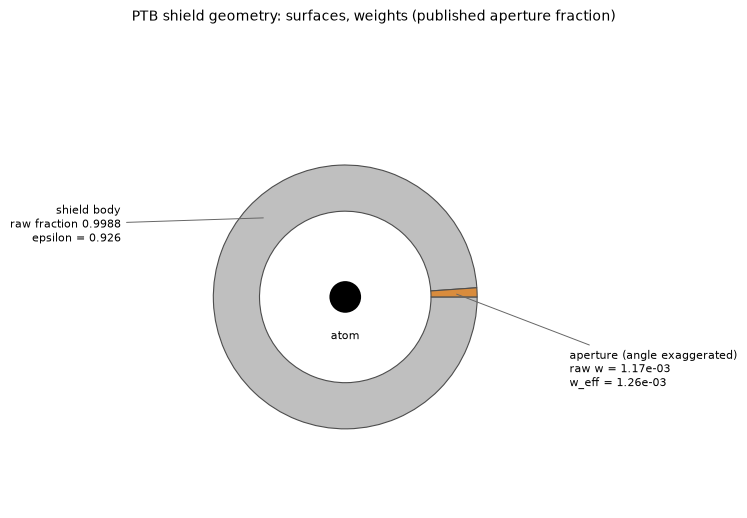

In [7]:
def ptb_shield_schematic(ax, w_raw, epsilon, w_eff):
    """Cross-section schematic of PTB's shield-and-aperture geometry (Nosske
    et al., arXiv:2507.14030): a reflective shield body at raw fraction
    `1 - w_raw` and interior emissivity `epsilon`, pierced by one aperture at
    its published raw fraction `w_raw`. The aperture's reflection-corrected
    effective fraction `w_eff` is annotated, not drawn as a second angle,
    since it is a property of the radiation reaching the atom, not of the
    raw geometry."""
    aperture_span = max(w_raw * 360.0, 4.0)
    ax.add_patch(
        mpatches.Wedge(
            (0, 0),
            1.0,
            aperture_span,
            360.0,
            width=0.35,
            facecolor="0.75",
            edgecolor="0.3",
            linewidth=0.8,
        )
    )
    ax.add_patch(
        mpatches.Wedge(
            (0, 0),
            1.0,
            0.0,
            aperture_span,
            width=0.35,
            facecolor="#d98c3d",
            edgecolor="0.3",
            linewidth=0.8,
        )
    )
    ax.add_patch(mpatches.Circle((0, 0), 0.12, facecolor="black", zorder=5))
    ax.annotate("atom", xy=(0, 0), xytext=(0, -0.32), ha="center", fontsize=8)
    ax.annotate(
        f"shield body\nraw fraction {1 - w_raw:.4f}\nepsilon = {epsilon:.3f}",
        xy=(-0.6, 0.6),
        xytext=(-1.7, 0.55),
        ha="right",
        va="center",
        fontsize=8,
        arrowprops=dict(arrowstyle="-", color="0.4", lw=0.7),
    )
    mid = math.radians(aperture_span / 2.0)
    ax.annotate(
        f"aperture (angle exaggerated)\nraw w = {w_raw:.2e}\nw_eff = {w_eff:.2e}",
        xy=(0.825 * math.cos(mid), 0.825 * math.sin(mid)),
        xytext=(1.7, -0.55),
        ha="left",
        va="center",
        fontsize=8,
        arrowprops=dict(arrowstyle="-", color="0.4", lw=0.7),
    )
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-1.6, 1.6)
    ax.set_aspect("equal")
    ax.axis("off")


ptb_w_raw, ptb_epsilon = PTB_POINTS[1][1], PTB_POINTS[1][2]
ptb_w_eff = engine_effective_weight(ptb_w_raw, ptb_epsilon)

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ptb_shield_schematic(ax, ptb_w_raw, ptb_epsilon, ptb_w_eff)
fig.suptitle(
    "PTB shield geometry: surfaces, weights (published aperture fraction)",
    fontsize=10,
    y=0.97,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

In [8]:
ptb_evals = [
    (label, w, epsilon, ptb_closed_form(w, epsilon), engine_effective_weight(w, epsilon))
    for label, w, epsilon in PTB_POINTS
]
_, w1, eps1, pub1, eng1 = ptb_evals[0]
_, w2, eps2, pub2, eng2 = ptb_evals[1]

worked_example_surfaces = (
    RadiationSurface(name="shield", weight=0.9, temperature_k=100.0, emissivity=0.5),
    RadiationSurface(name="aperture", weight=0.1, temperature_k=300.0),
)
worked_example_shift = bbr_environment_pivot_perturbation(worked_example_surfaces, sr87)
print(
    f"(P-1)_BBR, illustrative check (shield 100 K / eps=0.5, aperture 300 K): "
    f"{worked_example_shift:+.6e}"
)

ptb_row1 = (
    f"| Reflection-corrected weight formula, w={w1:.3f}, eps={eps1:.3f} (Eq. 3) (1) "
    f"| {pub1:.12f} | {eng1:.12f} | abs diff {abs(pub1 - eng1):.1e} |"
)
ptb_row2 = (
    f"| Apparatus operating point, w={w2:.2e}, eps={eps2:.3f} (Nosske Sec. 3) (2) "
    f"| {pub2:.12f} | {eng2:.12f} | abs diff {abs(pub2 - eng2):.1e} |"
)
ptb_row3 = (
    "| Position-scan differential shift (Nosske Eq. 4) (3) "
    "| measured -3.33(3)e-15; their model -3.32(7)e-15 "
    "| not reproduced (quoted only) | n/a |"
)
ptb_table_md = "\n".join(
    [
        "| quantity | published value | engine value | agreement |",
        "|---|---|---|---|",
        ptb_row1,
        ptb_row2,
        ptb_row3,
        "",
        "1. Formula transcription check, this project's illustrative (w, eps).",
        "2. PTB's own published apparatus w and epsilon, exact to displayed precision.",
        "3. Their own validation of their model; shield T-set not published.",
    ]
)
display(Markdown(ptb_table_md))

(P-1)_BBR, illustrative check (shield 100 K / eps=0.5, aperture 300 K): -1.017663e-15


| quantity | published value | engine value | agreement |
|---|---|---|---|
| Reflection-corrected weight formula, w=0.100, eps=0.500 (Eq. 3) (1) | 0.181818181818 | 0.181818181818 | abs diff 0.0e+00 |
| Apparatus operating point, w=1.17e-03, eps=0.926 (Nosske Sec. 3) (2) | 0.001263380795 | 0.001263380795 | abs diff 0.0e+00 |
| Position-scan differential shift (Nosske Eq. 4) (3) | measured -3.33(3)e-15; their model -3.32(7)e-15 | not reproduced (quoted only) | n/a |

1. Formula transcription check, this project's illustrative (w, eps).
2. PTB's own published apparatus w and epsilon, exact to displayed precision.
3. Their own validation of their model; shield T-set not published.

The rows above land within floating-point roundoff at every point
checked, including PTB's actual near-1e-3 aperture fraction. E37's
enclosure-and-apertures topology reduces to this exact formula for one
aperture by derivation; no fitting to PTB's numbers was involved in
reaching that reduction.

What this validates is narrower than a shift reproduction. It confirms
that the paper's closed-form weight arithmetic is transcribed
correctly, and that the engine's multi-surface evaluation reduces to
it exactly. A full shift reproduction would need a complete
shield-temperature reconstruction of PTB's own chamber carried end to
end; this section stops at the formula-transcription check.

PTB's own shield-body finite-element simulation and its position-scan
validation (a measured differential shift of `-3.33(3)e-15` against a
model prediction of `-3.32(7)e-15`) are not published as a
machine-readable temperature set this project could replay. This
section's claim therefore stops at formula transcription, a real but
strictly weaker statement than the reproducibility cases notebooks 06
and 09 make against NPL's and Bothwell's own measured numbers.

## 4. Validation anchor 2: the JILA temperature-step check

During the January-March 2025 BACON frequency-ratio comparison, JILA's
Sr1 team deliberately dropped the clock's operating temperature by 2.5
degrees Celsius on one comparison day, from 22.1 C to 19.6 C. They
used the predicted change in the BBR correction as a live check on the
registry formula's own temperature dependence (A. Aeppli, PhD thesis,
University of Colorado Boulder (2025), Appendix B; apparatus described
in Aeppli et al., PRL 133, 023401 (2024)).

This is a single-point consistency anchor: it tests whether E32's `T`
dependence tracks a real, deliberately introduced temperature step,
using the same registry coefficients this notebook has used
throughout. Section 3's PTB aperture check and section 7's position
scan below are this notebook's spatial validations. This one checks
the temperature axis alone, at a single fixed geometry.

The cell below computes the same predicted change with
`bbr_pivot_perturbation` at the two operating temperatures, and the
table beneath it lines the result up against the thesis's own
polynomial and its published confirmation.

In [9]:
T_HIGH_K = 22.1 + 273.15  # nominal operating temperature
T_LOW_K = 19.6 + 273.15  # the deliberately dropped temperature

shift_high = bbr_pivot_perturbation(T_HIGH_K, sr87)
shift_low = bbr_pivot_perturbation(T_LOW_K, sr87)
predicted_delta = shift_low - shift_high

print(f"T_high (22.1 C):  {T_HIGH_K:.2f} K   (P-1)_BBR = {shift_high:+.6e}")
print(f"T_low  (19.6 C):  {T_LOW_K:.2f} K   (P-1)_BBR = {shift_low:+.6e}")
print()
print(f"predicted change, low minus high:  {predicted_delta:+.3e}")
part_in_50 = abs(predicted_delta) / 50.0
print(f"part-in-50 characterization on this predicted change: {part_in_50:.2e}")

# Cross-check with the thesis's own locally fit dynamic polynomial
# (Aeppli 2025, Eq. 6.5: eta_6 = -0.132606, eta_8 = -0.011413,
# eta_10 = -0.009013 Hz; same Middelmann static term), evaluated with
# the identical E32 structure, so the two coefficient sets can be
# compared on this exact prediction.
NU0 = sr87.clock_frequency_hz
STATIC_HZ = -2.13023
THESIS_ETA = {6: -0.132606, 8: -0.011413, 10: -0.009013}


def thesis_bbr(t_k: float) -> float:
    x = t_k / 300.0
    dyn = sum(eta * x**n for n, eta in THESIS_ETA.items())
    return (STATIC_HZ * x**4 + dyn) / NU0


thesis_delta = thesis_bbr(T_LOW_K) - thesis_bbr(T_HIGH_K)
coef_set_diff = abs(thesis_delta - predicted_delta)
print(f"thesis-polynomial predicted change (low minus high):   {thesis_delta:+.6e}")
print(f"registry-polynomial predicted change (low minus high): {predicted_delta:+.6e}")
print(f"coefficient-set difference on this prediction: {coef_set_diff:.1e}")

jila_row5 = (
    "| Published clock-ratio confirmation (5) "
    "| steady to better than 4e-18; part-in-50 characterization |"
)
jila_table_md = "\n".join(
    [
        "| quantity | value |",
        "|---|---|",
        f"| Engine (registry polynomial) predicted change (1) | {predicted_delta:+.6e} |",
        f"| Thesis-polynomial predicted change (2) | {thesis_delta:+.6e} |",
        "| Thesis's own quoted predicted change (3) | ~2e-16 (1 significant figure) |",
        f"| Coefficient-set difference on this prediction (4) | {coef_set_diff:.1e} |",
        jila_row5,
        "",
        "1. This notebook's live `bbr_pivot_perturbation` call, T_low minus T_high.",
        "2. Aeppli 2025 Eq. 6.5 coefficients, same E32 structure, evaluated here.",
        "3. The thesis's stated approximate figure, Appendix B, quoted.",
        "4. abs(row 1 minus row 2), how far the two coefficient sets disagree.",
        "5. Their own measurement floor (Aeppli thesis); quoted for context.",
    ]
)
display(Markdown(jila_table_md))

T_high (22.1 C):  295.25 K   (P-1)_BBR = -4.978068e-15
T_low  (19.6 C):  292.75 K   (P-1)_BBR = -4.805397e-15

predicted change, low minus high:  +1.727e-16
part-in-50 characterization on this predicted change: 3.45e-18
thesis-polynomial predicted change (low minus high):   +1.726673e-16
registry-polynomial predicted change (low minus high): +1.726712e-16
coefficient-set difference on this prediction: 3.9e-21


| quantity | value |
|---|---|
| Engine (registry polynomial) predicted change (1) | +1.726712e-16 |
| Thesis-polynomial predicted change (2) | +1.726673e-16 |
| Thesis's own quoted predicted change (3) | ~2e-16 (1 significant figure) |
| Coefficient-set difference on this prediction (4) | 3.9e-21 |
| Published clock-ratio confirmation (5) | steady to better than 4e-18; part-in-50 characterization |

1. This notebook's live `bbr_pivot_perturbation` call, T_low minus T_high.
2. Aeppli 2025 Eq. 6.5 coefficients, same E32 structure, evaluated here.
3. The thesis's stated approximate figure, Appendix B, quoted.
4. abs(row 1 minus row 2), how far the two coefficient sets disagree.
5. Their own measurement floor (Aeppli thesis); quoted for context.

The engine's live delta comes out at `1.7e-16` in magnitude. The
thesis quotes its own predicted change as approximately `2e-16`, the
same number as the engine's at one significant digit. The cell above
evaluates the thesis's own locally fit polynomial beside this
registry's, and the two coefficient sets agree on this prediction to a
few parts in `1e-21`.

The published confirmation is the clock ratio: Aeppli's thesis reports
the measured ratio held steady to better than `4e-18` across the
temperature step. The thesis states that this stability leads to a
direct characterization of the BBR correction's temperature scaling,
to approximately a part in 50. A part in 50 on a `1.7e-16` predicted
change is about `3e-18`, comparable to the thesis's own `4e-18`
clock-ratio floor.

This confirmation is coarse, order-of-magnitude: the clock-ratio floor
sets the precision ceiling, well short of the machine-precision
agreement section 3's formula check reaches. It is also a single
operating point, one temperature step on one platform, so it says
nothing about spatial non-uniformity. Section 3 above is this
notebook's validation anchor for the multi-surface machinery; this
section anchors the temperature-dependence formula alone.

## 5. The field-deployment sensitivity band

A transportable clock without lab-grade thermal engineering typically
has a handful of contact-thermometer readings on real surfaces, each
with its own calibration uncertainty. It does not have PTB's cooled
copper shield or NIST Yb's carbon-nanotube-coated enclosure.

The scenario below reuses the same `SCENARIO_SURFACES` chamber drawn
in section 1, with sensor uncertainties of 0.5 to 2 K per surface,
well within what an uncooled RTD or thermistor on a field unit can
deliver.

`bbr_environment_pivot_uncertainty` propagates those three sensor
uncertainties into a band on the shift, in two modes. The independent
mode assumes uncorrelated sensor noise. The correlated mode assumes a
shared calibration-chain error moving every sensor together, the same
motivation Aeppli's thesis gives for its own linear-pooling
combination.
`bbr_environment_effective_temperatures` reports the per-moment
effective temperatures directly, so the divergence between `T_eff,4`
and `T_eff,6` is a real printed number.

In [10]:
scenario_shift = bbr_environment_pivot_perturbation(SCENARIO_SURFACES, sr87)
sigma_indep, indep_included = bbr_environment_pivot_uncertainty(
    SCENARIO_SURFACES, sr87, correlated=False
)
sigma_corr, corr_included = bbr_environment_pivot_uncertainty(
    SCENARIO_SURFACES, sr87, correlated=True
)
t_eff = bbr_environment_effective_temperatures(SCENARIO_SURFACES, sr87)

print("surfaces:")
for surface in SCENARIO_SURFACES:
    print(
        f"  {surface.name:12s} weight={surface.weight:.2f}  T={surface.temperature_k:.1f} K "
        f" +/- {surface.temperature_uncertainty_k:.1f} K"
    )
print()
print(f"(P-1)_BBR, this environment:   {scenario_shift:+.6e}")
print(
    f"band, independent sensors:     +/- {sigma_indep:.3e}  "
    f"(temperature uncertainty included: {indep_included})"
)
print(
    f"band, correlated sensors:      +/- {sigma_corr:.3e}  "
    f"(temperature uncertainty included: {corr_included})"
)
print()
print("per-moment effective temperatures:")
for n in sorted(t_eff):
    print(f"  T_eff,{n}:  {t_eff[n]:.4f} K")
print(f"T_eff,6 - T_eff,4 divergence:   {t_eff[6] - t_eff[4]:+.4f} K")

surfaces:
  chamber      weight=0.87  T=296.0 K  +/- 0.5 K
  hot_window   weight=0.08  T=320.0 K  +/- 1.0 K
  cold_window  weight=0.05  T=285.0 K  +/- 2.0 K

(P-1)_BBR, this environment:   -5.148935e-15
band, independent sensors:     +/- 3.219e-17  (temperature uncertainty included: True)
band, correlated sensors:      +/- 4.426e-17  (temperature uncertainty included: True)

per-moment effective temperatures:
  T_eff,4:  297.6327 K
  T_eff,6:  297.8242 K
  T_eff,8:  298.0298 K
  T_eff,10:  298.2506 K
T_eff,6 - T_eff,4 divergence:   +0.1915 K


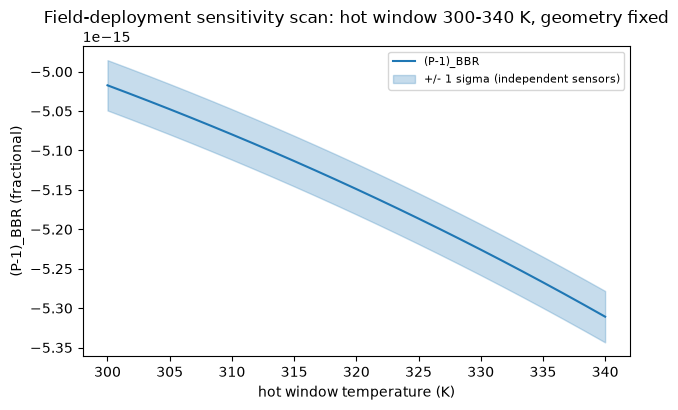

shift at T_hot=300 K:  -5.0173e-15  +/- 3.19e-17
shift at T_hot=340 K:  -5.3108e-15  +/- 3.26e-17


In [11]:
HOT_WINDOW_SCAN_K = np.linspace(300.0, 340.0, 25)
scan_shift = np.empty_like(HOT_WINDOW_SCAN_K)
scan_band = np.empty_like(HOT_WINDOW_SCAN_K)

for i, t_hot in enumerate(HOT_WINDOW_SCAN_K):
    surfaces = (
        RadiationSurface(
            name="chamber",
            weight=0.87,
            temperature_k=296.0,
            temperature_uncertainty_k=0.5,
        ),
        RadiationSurface(
            name="hot_window",
            weight=0.08,
            temperature_k=t_hot,
            temperature_uncertainty_k=1.0,
        ),
        RadiationSurface(
            name="cold_window",
            weight=0.05,
            temperature_k=285.0,
            temperature_uncertainty_k=2.0,
        ),
    )
    scan_shift[i] = bbr_environment_pivot_perturbation(surfaces, sr87)
    scan_band[i], _ = bbr_environment_pivot_uncertainty(surfaces, sr87, correlated=False)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(HOT_WINDOW_SCAN_K, scan_shift, color="C0", label="(P-1)_BBR")
ax.fill_between(
    HOT_WINDOW_SCAN_K,
    scan_shift - scan_band,
    scan_shift + scan_band,
    color="C0",
    alpha=0.25,
    label="+/- 1 sigma (independent sensors)",
)
ax.set_xlabel("hot window temperature (K)")
ax.set_ylabel("(P-1)_BBR (fractional)")
ax.set_title("Field-deployment sensitivity scan: hot window 300-340 K, geometry fixed")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"shift at T_hot=300 K:  {scan_shift[0]:+.4e}  +/- {scan_band[0]:.2e}")
print(f"shift at T_hot=340 K:  {scan_shift[-1]:+.4e}  +/- {scan_band[-1]:.2e}")

A lab without PTB-grade thermal engineering can still use this tool
the way it already reads any uncertainty budget line. Sensor readings
go in, each with its own calibration uncertainty. A defensible BBR
shift and its error band come out. Sensor readings and their
calibration uncertainties are the only required inputs; a shielded
enclosure and a finite-element thermal model both stay optional
refinements.

The correlated band above is always wider than the independent band.
That ordering comes directly from E37's derivation: its coefficient
partials all share the same sign, and that same-sign relationship is
what pins the correlated band as the wider one every time. Choosing
between the two bands is a factual question about the sensors, whether
their readings share a calibration chain or carry independent errors;
it is never a tuning knob for a smaller number.

The scenario's own numbers make section 2's point concrete. `T_eff,4`
and `T_eff,6`, the effective temperatures matched to the shift's
fourth-power and sixth-power terms, differ by about two-tenths of a
kelvin in this baseline scenario. That gap is section 2's headline
point, the single-temperature approximation breaking down. Section 2
showed that breakdown in an abstract sweep; this scenario shows the
same breakdown in one realistic case.

## 6. Published exchange factors as engine input

Every weight used so far in this notebook, `SCENARIO_SURFACES` in
section 1 and the PTB aperture fraction in section 3, is a
solid-angle or exchange-factor fraction. That is the kind of number a
Monte Carlo ray tracer produces from a chamber's own CAD geometry.

Tobias Bothwell's 2022 JILA PhD thesis publishes that table for a
real strontium clock chamber. Section 2.5.1 derives the
exchange-factor formalism `T_i^4 = sum_j F_{i->j} T_j^4` from first
principles and computes `F_{i->j}` for every surface with a Monte
Carlo ray tracer that propagates 50 million rays from the atom
location on a 3D CAD replica of the vacuum system (T. Bothwell, PhD
thesis, University of Colorado Boulder (2022), Section 2.5.1, p. 39).

Table 2.7 lists the resulting exchange factor for each of seven named
surfaces (p. 40). The cells below transcribe that table and feed it
through the same `RadiationSurface`/`bbr_environment_pivot_perturbation`
path every earlier section already exercises. The same code that ran an
illustrative sweep in section 2 and a formula check in section 3 now
runs on a published lab's own measured chamber.

One physics point matters before the numbers: a ray-traced exchange
factor already has every reflection built into it. A Monte Carlo ray
that bounces off several surfaces before it is finally absorbed still
contributes to the exchange factor of whichever surface absorbs it
last.

That differs from section 3's PTB aperture formula, where a single
partially reflective enclosure (interior emissivity `epsilon`) sits
behind small direct-view holes and the engine's `emissivity` field
applies its own separate reflection correction on top of a raw
geometric weight. Feeding Table 2.7 into the engine means leaving
every surface's `emissivity` field at its default `None`: setting it
on a ray-traced exchange factor would apply PTB's reflection
correction a second time, on top of the reflections the ray tracer
already resolved.

Table 2.5 lists the emissivities that fed that ray tracer in the first
place (glass viewports 0.91, stainless steel 0.08, sapphire 0.54, oven
nozzle 0.82, p. 39). This section never feeds any of them back into
the engine, because that information already shaped Table 2.7's
exchange factors on the way in.

In [12]:
# Bothwell thesis, Table 2.7 "Vacuum chamber generalized exchange factors" (p. 40),
# transcribed exactly at the table's own published 3-sig-fig precision. The oven nozzle's
# operating temperature (575 C, Fig. 2.3 caption, p. 17) is real and published but lies far
# outside the engine's validated 50-350 K BBR fit window, demonstrated below.
BOTHWELL_EXCHANGE_FACTORS_RAW = {
    "heated_sapphire_window": 8.81e-4,
    "viewport_2_75in_extended_flange": 1.47e-2,
    "viewport_2_75in_direct_flange": 1.18e-1,
    "viewport_6in": 5.39e-1,
    "glass_cell": 1.08e-3,
    "metal_chamber_tubing_slower": 3.26e-1,
    "oven_nozzle": 2.15e-5,
}
raw_sum7 = math.fsum(BOTHWELL_EXCHANGE_FACTORS_RAW.values())
print(f"Table 2.7 as published, all seven rows, sums to {raw_sum7:.5f} (3-sig-fig rounding)")

bothwell_table_md = "\n".join(
    [
        "| component (Table 2.7) | exchange factor |",
        "|---|---|",
        *(
            f"| {name.replace('_', ' ')} | {value:.3e} |"
            for name, value in BOTHWELL_EXCHANGE_FACTORS_RAW.items()
        ),
        f"| **sum, as published** | **{raw_sum7:.5f}** |",
    ]
)
display(Markdown(bothwell_table_md))

Table 2.7 as published, all seven rows, sums to 0.99968 (3-sig-fig rounding)


| component (Table 2.7) | exchange factor |
|---|---|
| heated sapphire window | 8.810e-04 |
| viewport 2 75in extended flange | 1.470e-02 |
| viewport 2 75in direct flange | 1.180e-01 |
| viewport 6in | 5.390e-01 |
| glass cell | 1.080e-03 |
| metal chamber tubing slower | 3.260e-01 |
| oven nozzle | 2.150e-05 |
| **sum, as published** | **0.99968** |

In [13]:
T_SETPOINT_K = 22.0 + 273.15  # thesis Section 2.3.1, p. 20: "All setpoints ... are set to 22 C"
T_OVEN_NOZZLE_K = 575.0 + 273.15  # thesis Fig. 2.3 caption, p. 17

# Renormalize the full table to sum to exactly 1 (BBR_ENVIRONMENT_WEIGHT_TOLERANCE) before
# attempting to build an environment, so the ValueError below is the temperature-range guard,
# not a weight-sum rejection from the table's own 3-sig-fig rounding.
norm7 = {name: value / raw_sum7 for name, value in BOTHWELL_EXCHANGE_FACTORS_RAW.items()}
full_surfaces = tuple(
    RadiationSurface(
        name=name,
        weight=weight,
        temperature_k=T_OVEN_NOZZLE_K if name == "oven_nozzle" else T_SETPOINT_K,
    )
    for name, weight in norm7.items()
)
try:
    bbr_environment_pivot_perturbation(full_surfaces, sr87)
    print("no error raised (unexpected)")
except ValueError as exc:
    print("engine correctly refuses the published oven-nozzle temperature:")
    print(f"  {exc}")

# How small is the oven nozzle's own row, and how large could its omission be? Both are
# answerable directly from Table 2.7's own transcribed values and the registry coefficients the
# rejected call above would have used, without extrapolating anything past a validated window.
nozzle_factor = BOTHWELL_EXCHANGE_FACTORS_RAW["oven_nozzle"]
next_smallest_name, next_smallest_factor = min(
    (
        (name, value)
        for name, value in BOTHWELL_EXCHANGE_FACTORS_RAW.items()
        if name != "oven_nozzle"
    ),
    key=lambda item: item[1],
)
largest_name, largest_factor = max(BOTHWELL_EXCHANGE_FACTORS_RAW.items(), key=lambda item: item[1])
print()
print(
    f"oven nozzle exchange factor {nozzle_factor:.2e} is "
    f"{next_smallest_factor / nozzle_factor:.0f}x smaller than the next-smallest row "
    f"({next_smallest_name.replace('_', ' ')}, {next_smallest_factor:.2e}) and "
    f"{largest_factor / nozzle_factor:.1e}x smaller than the largest row "
    f"({largest_name.replace('_', ' ')}, {largest_factor:.2e})"
)

# The physically citable bound on the excluded nozzle's own contribution is its static T^4 term
# alone, at the published 848.15 K operating temperature; the dynamic terms extrapolated that far
# past their 50-350 K validated support (CONVENTIONS.md E32/E37) are exactly the invalid move the
# ValueError above blocks, so the second number below is computed only to show why it is not the
# bound this section uses.
BBR_T0_K = 300.0  # BBR_REFERENCE_TEMPERATURE_K, the same reference every moment here uses
coeffs_sr87 = sr87.resolve_bbr_coefficients()
nozzle_weight = norm7["oven_nozzle"]
nozzle_t_ratio = T_OVEN_NOZZLE_K / BBR_T0_K
NOZZLE_STATIC_BOUND = (
    coeffs_sr87.nu_stat_300k_hz * nozzle_weight * nozzle_t_ratio**4 / sr87.clock_frequency_hz
)
nozzle_dyn_extrapolated = (
    sum(coeff * nozzle_weight * nozzle_t_ratio**n for n, coeff in coeffs_sr87.dyn_coeffs_hz.items())
    / sr87.clock_frequency_hz
)
NOZZLE_FULL_EXTRAPOLATED = NOZZLE_STATIC_BOUND + nozzle_dyn_extrapolated
print()
print(f"oven nozzle, static T^4 term only (the citable omission bound): {NOZZLE_STATIC_BOUND:+.2e}")
print(
    f"oven nozzle, dynamic terms extrapolated to 848 K too (invalid, shown for scale only): "
    f"{NOZZLE_FULL_EXTRAPOLATED:+.2e}"
)

engine correctly refuses the published oven-nozzle temperature:
  radiation environment surface 'oven_nozzle': temperature_k=848.15 K is outside the validated BBR fit range [50.0, 350.0] K (CONVENTIONS.md E32/E37): hard rejection, not a silently-extrapolated fit past its published support.

oven nozzle exchange factor 2.15e-05 is 41x smaller than the next-smallest row (heated sapphire window, 8.81e-04) and 2.5e+04x smaller than the largest row (viewport 6in, 5.39e-01)

oven nozzle, static T^4 term only (the citable omission bound): -6.82e-18
oven nozzle, dynamic terms extrapolated to 848 K too (invalid, shown for scale only): -2.67e-17


The engine's validity window is E32's `50-350 K` fit range
(`docs/CONVENTIONS.md` section 13), enforced per surface, and the oven
nozzle's real 848.15 K operating temperature sits far outside it. That
rejection is correct behavior: silently extrapolating the registry's
fitted polynomial past its published support is how a wrong clock
correction gets made, the same reasoning E32's own validity check
already applies to a single uniform temperature. The remaining six
surfaces carry the demonstration instead. Its own exchange factor,
`2.15e-05`, is the smallest row in Table 2.7: about `41`x smaller than
the next-smallest row (the heated sapphire window, `8.81e-04`) and
roughly `2.5e+04`x smaller than the table's largest row (the 6-inch CF
viewport glass, `5.39e-01`).

Dropping it and renormalizing the other six to sum to 1 leaves an
omission bounded at the `-6.82e-18` scale by its static `T^4` term
alone, the physically citable figure. Extrapolating the fitted dynamic
polynomial all the way to 848 K on top of that, `-2.67e-17`, is the
invalid move the `ValueError` above blocks. That second number only
demonstrates why the static-term bound is the one this section carries
forward.

The thesis states an explicit temperature for exactly one
non-controlled surface, the oven nozzle just excluded. For the
remaining six, it publishes a chamber-wide claim (Section 2.3.1, p. 19:
"we improve the overall thermal homogeneity of JILA Sr1 by more than a
factor of 10, limiting thermal gradients across the chamber to less
than 100 mK"). It publishes no separate setpoint for the heated
sapphire window, the glass cell, or the uncontrolled metal chamber and
tubing individually.

The cell below assigns all six the 22 C viewport setpoint. That
setpoint is this notebook's own documented assumption for those three
surfaces, bounded by the same 100 mK chamber-wide claim; the thesis
itself publishes only that chamber-wide number, with no row-by-row
breakdown to transcribe. Per-surface temperature uncertainties use the
thesis's own two published sensor specifications: 50 mK for the
general array of 50 kOhm thermistors, and 13 mK for the 6" CF
viewports specifically, whose dominant exchange factor earned them an
improved TFPRT-based calibration (both p. 40).

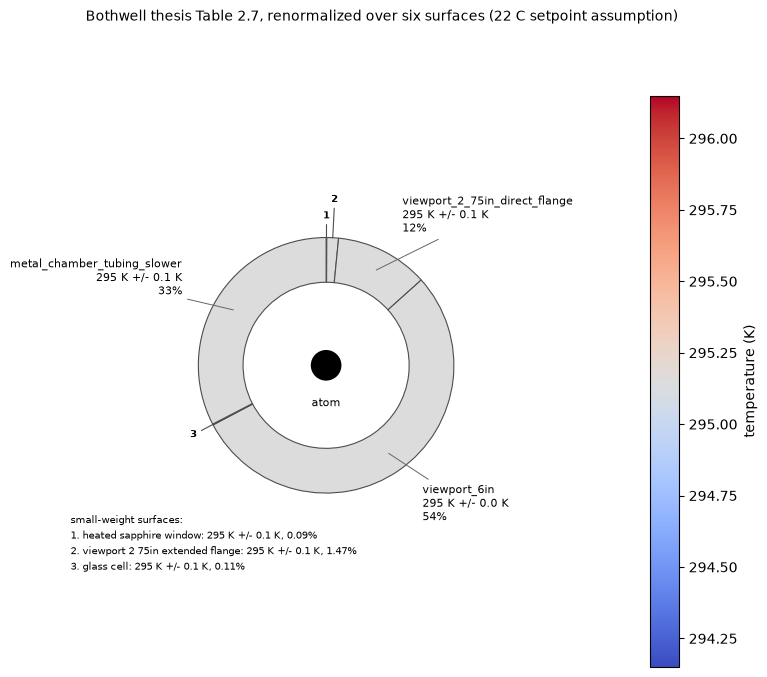

In [14]:
BOTHWELL_TABLE27_CONTROLLED = {
    name: value for name, value in BOTHWELL_EXCHANGE_FACTORS_RAW.items() if name != "oven_nozzle"
}
raw_sum6 = math.fsum(BOTHWELL_TABLE27_CONTROLLED.values())
norm6 = {name: value / raw_sum6 for name, value in BOTHWELL_TABLE27_CONTROLLED.items()}

BOTHWELL_SENSOR_UNCERTAINTY_K = {
    name: (0.013 if name == "viewport_6in" else 0.050) for name in BOTHWELL_TABLE27_CONTROLLED
}

thesis_surfaces = tuple(
    RadiationSurface(
        name=name,
        weight=norm6[name],
        temperature_k=T_SETPOINT_K,
        temperature_uncertainty_k=BOTHWELL_SENSOR_UNCERTAINTY_K[name],
    )
    for name in BOTHWELL_TABLE27_CONTROLLED
)

fig, ax = plt.subplots(figsize=(7.8, 7.0))
# Three of Table 2.7's six rows are under 2%: inline labels for those three would overlap at
# this wedge count, so anything under 3% gets a numbered tick and a side list instead
# (`chamber_schematic`'s `side_list_below` parameter).
chamber_schematic(ax, thesis_surfaces, side_list_below=0.03)
fig.suptitle(
    "Bothwell thesis Table 2.7, renormalized over six surfaces (22 C setpoint assumption)",
    fontsize=10,
    y=0.98,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

In [15]:
thesis_shift = bbr_environment_pivot_perturbation(thesis_surfaces, sr87)
thesis_sigma_indep, _ = bbr_environment_pivot_uncertainty(thesis_surfaces, sr87, correlated=False)
thesis_sigma_corr, _ = bbr_environment_pivot_uncertainty(thesis_surfaces, sr87, correlated=True)
thesis_t_eff = bbr_environment_effective_temperatures(thesis_surfaces, sr87)

# Table 2.1, p. 22: the thesis's own net correction from ray-traced-model temperature to the
# directly measured (in-vacuum TFPRT probe) atom temperature, and its combined uncertainty.
THESIS_ATOM_TEMPERATURE_CORRECTION_K = 0.0191
THESIS_ATOM_TEMPERATURE_UNCERTAINTY_K = 0.0029
THESIS_TEMPERATURE_UNCERTAINTY_FRAC = 2.0e-19  # Table 2.1, p. 22, quoted directly

thesis_corrected_t_k = T_SETPOINT_K + THESIS_ATOM_TEMPERATURE_CORRECTION_K
thesis_corrected_shift = bbr_pivot_perturbation(thesis_corrected_t_k, sr87)

print(f"(P-1)_BBR, six-surface published environment:  {thesis_shift:+.6e}")
print(
    f"band, independent sensors:  +/- {thesis_sigma_indep:.3e}   "
    f"(raw thermistor specs, this notebook's assignment)"
)
print(f"band, correlated sensors:   +/- {thesis_sigma_corr:.3e}")
print()
print("per-moment effective temperatures (all surfaces at one assumed T, exact reduction):")
for n in sorted(thesis_t_eff):
    print(f"  T_eff,{n}:  {thesis_t_eff[n]:.4f} K")
print()
print(f"thesis Table 2.1 corrected atom temperature: {thesis_corrected_t_k:.4f} K")
print(f"single-T shift at that temperature:          {thesis_corrected_shift:+.6e}")
print(
    f"abs difference from this section's environment shift: "
    f"{abs(thesis_shift - thesis_corrected_shift):.3e}"
)

thesis_compare_md = "\n".join(
    [
        "| quantity | Bothwell thesis (published) | this section (engine) |",
        "|---|---|---|",
        f"| Atom temperature | {T_SETPOINT_K:.2f} K setpoint (1), "
        f"{thesis_corrected_t_k:.4f} K corrected (2) "
        f"| T_eff,4 = {thesis_t_eff[4]:.4f} K (3) |",
        f"| Temperature uncertainty | {THESIS_ATOM_TEMPERATURE_UNCERTAINTY_K * 1e3:.1f} mK, "
        f"combined (4) | independent {thesis_sigma_indep:.3e}, "
        f"correlated {thesis_sigma_corr:.3e} (5) |",
        f"| Fractional BBR uncertainty, temperature only | "
        f"{THESIS_TEMPERATURE_UNCERTAINTY_FRAC:.1e} (4) "
        f"| {thesis_sigma_indep:.3e} (6) |",
        f"| (P-1)_BBR at the corrected temperature | {thesis_corrected_shift:+.6e} (2) "
        f"| {thesis_shift:+.6e} (3) |",
        "",
        "1. Section 2.3.1's viewport/flange servo setpoint, p. 20, used for all six surfaces here.",
        "2. Table 2.1's net correction (+19.1 mK) applied to the setpoint, p. 22.",
        "3. This section's six-surface environment; every surface shares one assumed "
        "temperature, so every T_eff,n reduces to that same value exactly.",
        "4. Table 2.1's Total row, p. 22.",
        "5. This section's own per-surface sensor-spec propagation "
        "(`bbr_environment_pivot_uncertainty`), not a reproduction of Table 2.1's calibration "
        "chain.",
        "6. Independent-mode band from row above, repeated for the ratio in the text below.",
    ]
)
display(Markdown(thesis_compare_md))

(P-1)_BBR, six-surface published environment:  -4.971069e-15
band, independent sensors:  +/- 1.489e-18   (raw thermistor specs, this notebook's assignment)
band, correlated sensors:   +/- 2.218e-18

per-moment effective temperatures (all surfaces at one assumed T, exact reduction):
  T_eff,4:  295.1500 K
  T_eff,6:  295.1500 K
  T_eff,8:  295.1500 K
  T_eff,10:  295.1500 K

thesis Table 2.1 corrected atom temperature: 295.1691 K
single-T shift at that temperature:          -4.972405e-15
abs difference from this section's environment shift: 1.336e-18


| quantity | Bothwell thesis (published) | this section (engine) |
|---|---|---|
| Atom temperature | 295.15 K setpoint (1), 295.1691 K corrected (2) | T_eff,4 = 295.1500 K (3) |
| Temperature uncertainty | 2.9 mK, combined (4) | independent 1.489e-18, correlated 2.218e-18 (5) |
| Fractional BBR uncertainty, temperature only | 2.0e-19 (4) | 1.489e-18 (6) |
| (P-1)_BBR at the corrected temperature | -4.972405e-15 (2) | -4.971069e-15 (3) |

1. Section 2.3.1's viewport/flange servo setpoint, p. 20, used for all six surfaces here.
2. Table 2.1's net correction (+19.1 mK) applied to the setpoint, p. 22.
3. This section's six-surface environment; every surface shares one assumed temperature, so every T_eff,n reduces to that same value exactly.
4. Table 2.1's Total row, p. 22.
5. This section's own per-surface sensor-spec propagation (`bbr_environment_pivot_uncertainty`), not a reproduction of Table 2.1's calibration chain.
6. Independent-mode band from row above, repeated for the ratio in the text below.

The six-surface environment collapses to a single effective
temperature by construction. Every `T_eff,n` above equals `295.15 K`
exactly, because this section's documented assumption puts every
included surface at the same 22 C setpoint. That collapse is a real,
independent confirmation of section 2's headline point. Section 2
showed that point with an illustrative sweep; this section shows the
same collapse with an actual published chamber. JILA's Sr1 team
engineered its thermal environment specifically to keep the spread
across every dominant surface within the sub-10-K regime, where
section 2's sweep shows the single-temperature approximation is exact.
Table 2.7's own exchange factors, run through this notebook's engine,
land inside that same regime.

The table's fourth row, "(P-1)_BBR at the corrected temperature,"
holds two different calculations side by side. The right-hand entry,
`-4.971069e-15`, is this section's own six-surface engine output, the
number every paragraph on this page has been building toward. The
left-hand entry, `-4.972405e-15`, is a separate calculation: the
thesis's own bookkeeping (footnote 2), the `22 C` setpoint plus Table
2.1's published `+19.1 mK` net correction, evaluated as one single
temperature through the same registry polynomial
`bbr_pivot_perturbation` uses everywhere else in this notebook.

The collapse established above is why those two numbers agree to
`1.336e-18`. All six surfaces this section includes sit at the same
assumed `22 C`, so the six-surface weighted environment reduces
mathematically to a single temperature close to the thesis's own
corrected value. That agreement checks whether this section's engine
arithmetic reproduces the thesis's own bookkeeping correctly. The
collapse above makes it the expected outcome, and finding it confirms
the arithmetic works.

The excluded oven nozzle from section 6's opening cells sets the
precision either number in that row can claim. Its own static-term
bound, `-6.82e-18`, is larger than the `1.336e-18` agreement between
the two rows, so that agreement is meaningful at the roughly `1e-17`
scale the omitted nozzle term still allows.

The independent-mode uncertainty band this section computes,
`1.489e-18`, comes out roughly `7.4` times wider than the thesis's own
combined `2.0e-19`. That gap is informative: this section's
per-surface uncertainties are the raw manufacturer thermistor
specifications (`50 mK`, `13 mK`). The thesis's `2.9 mK` combined
figure is the product of a full calibration chain, a TFPRT
cross-comparison, an immersion-error measurement, and a self-heating
correction, which together squeeze the effective uncertainty down by
close to an order of magnitude. Feeding the engine a lab's raw sensor
specifications gives a conservative, wider band than a fully
characterized calibration would; the tool's output is only as tight as
what goes in.

## 7. Validation anchor 3: the PTB position-resolved scan

Section 3 validated PTB's aperture-and-enclosure weight formula at a
single fixed point, the apparatus's own operating fractions. Nosske et
al. go further and publish a genuine position-resolved check: they
scan the atoms from the BBR shield's center out through one of its two
end holes and compare a measured differential shift against their own
closed-form prediction at every scanned position.

That scan gives this notebook a kind of validation sections 3 and 4
cannot provide alone: an engine prediction checked against a
measurement as a function of position. The paper publishes enough
geometry to replay it end to end: both hole radii to `6 um`
(`0.484(6) mm`), the shield's `20 mm` length, the interior coating
emissivity `epsilon_in = 0.926(43)`, and the shield and room
temperatures during the scan (I. Nosske et al., arXiv:2507.14030, p.
6-8).

The paper's own solid-angle formula (their Eq. 2) is a different
closed form from Part B's disk formula below: it accounts for both of
the shield's end holes and the atom's axial position between them in
one expression. Part B's disk formula below models a single disk seen
from a single point; the paper's own expression is the richer geometry
this section validates against. Feeding its output through the
engine's existing PTB aperture-and-enclosure path (Eq. 3, already
validated in section 3) and the engine's existing single-temperature
evaluation (for the fully-outside limit) reproduces the paper's own
measured-versus-predicted position scan directly, with no adjustable
parameter beyond the paper's own published numbers.

Omega(0)/4pi = 1.169226e-03   (published: 1.17(3)e-3)


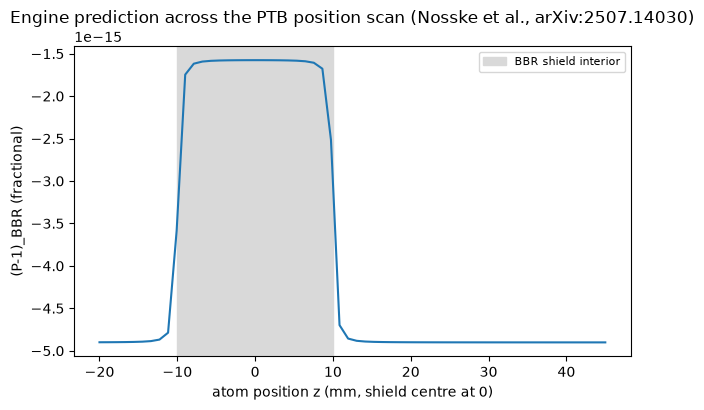

In [16]:
R1_MM = 0.484
R2_MM = 0.484
SHIELD_LENGTH_MM = 20.0  # Nosske et al., p. 4: "20 mm-long copper shield"
SHIELD_EPS_IN = 0.926  # Nosske et al., p. 6
T_SHIELD_K = -50.1 + 273.15  # Nosske et al., p. 7
T_OUT_K = 21.0 + 273.15  # Nosske et al., p. 7


def nosske_omega_over_4pi(z_mm, r1_mm=R1_MM, r2_mm=R2_MM, ell_mm=SHIELD_LENGTH_MM):
    """Nosske et al. (arXiv:2507.14030) Eq. 2: fractional solid angle Omega(z)/4pi under
    which the atoms see the shield's two end apertures, as a function of the atom's axial
    position z (mm) relative to the shield's own center."""
    term1 = 0.5 * (1.0 - math.sin(math.atan((z_mm + ell_mm / 2.0) / r1_mm)))
    term2 = 0.5 * (1.0 + math.sin(math.atan((z_mm - ell_mm / 2.0) / r2_mm)))
    return term1 + term2


w_center = nosske_omega_over_4pi(0.0)
print(f"Omega(0)/4pi = {w_center:.6e}   (published: 1.17(3)e-3)")

PTB_SCAN_Z_MM = np.linspace(-20.0, 45.0, 60)
ptb_scan_shift = np.empty_like(PTB_SCAN_Z_MM)
for i, z_mm in enumerate(PTB_SCAN_Z_MM):
    w_ap = nosske_omega_over_4pi(z_mm)
    surfaces = (
        RadiationSurface(name="aperture", weight=w_ap, temperature_k=T_OUT_K),
        RadiationSurface(
            name="shield", weight=1.0 - w_ap, temperature_k=T_SHIELD_K, emissivity=SHIELD_EPS_IN
        ),
    )
    ptb_scan_shift[i] = bbr_environment_pivot_perturbation(surfaces, sr87)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(PTB_SCAN_Z_MM, ptb_scan_shift, color="C0")
ax.axvspan(
    -SHIELD_LENGTH_MM / 2.0,
    SHIELD_LENGTH_MM / 2.0,
    color="0.85",
    zorder=0,
    label="BBR shield interior",
)
ax.set_xlabel("atom position z (mm, shield centre at 0)")
ax.set_ylabel("(P-1)_BBR (fractional)")
ax.set_title("Engine prediction across the PTB position scan (Nosske et al., arXiv:2507.14030)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [17]:
ptb_shift_center = bbr_environment_pivot_perturbation(
    (
        RadiationSurface(name="aperture", weight=w_center, temperature_k=T_OUT_K),
        RadiationSurface(
            name="shield",
            weight=1.0 - w_center,
            temperature_k=T_SHIELD_K,
            emissivity=SHIELD_EPS_IN,
        ),
    ),
    sr87,
)
# Far outside the shield, Omega(z)/4pi -> 1 exactly (Eq. 2's z -> +/-infinity limit), so the
# aperture's effective weight saturates at 1 and the environment reduces to the pure T_out
# single-temperature shift; this is the same exact single-surface reduction section 3 pins.
ptb_shift_outside = bbr_pivot_perturbation(T_OUT_K, sr87)
ptb_predicted_differential = ptb_shift_outside - ptb_shift_center

print(f"shift at shield centre (z=0):        {ptb_shift_center:+.6e}")
print(f"shift far outside the shield (z->inf): {ptb_shift_outside:+.6e}")
print(f"predicted differential (outside minus centre): {ptb_predicted_differential:+.3e}")

ptb_scan_compare_md = "\n".join(
    [
        "| quantity | value |",
        "|---|---|",
        f"| Engine prediction, outside minus centre (1) | {ptb_predicted_differential:+.3e} |",
        "| Nosske et al.'s own model prediction (2) | -3.32(7)e-15 |",
        "| Nosske et al.'s measured differential shift (3) | -3.33(3)e-15 |",
        f"| abs(engine minus their model) (4) "
        f"| {abs(ptb_predicted_differential - (-3.32e-15)):.1e} |",
        f"| abs(engine minus their measurement) (4) "
        f"| {abs(ptb_predicted_differential - (-3.33e-15)):.1e} |",
        "",
        "1. This notebook's live `nosske_omega_over_4pi` plus `bbr_environment_pivot_perturbation` "
        "call, the z -> +/-infinity analytic limit of Eq. 2/3 as the outside reference.",
        "2. Nosske et al., p. 8, their own closed-form prediction for the same comparison.",
        "3. Nosske et al., p. 8, the measured value their model is checked against.",
        "4. Both differences are well inside either published number's own quoted uncertainty "
        "(7e-17 and 3e-17 respectively).",
    ]
)
display(Markdown(ptb_scan_compare_md))

shift at shield centre (z=0):        -1.576494e-15
shift far outside the shield (z->inf): -4.901505e-15
predicted differential (outside minus centre): -3.325e-15


| quantity | value |
|---|---|
| Engine prediction, outside minus centre (1) | -3.325e-15 |
| Nosske et al.'s own model prediction (2) | -3.32(7)e-15 |
| Nosske et al.'s measured differential shift (3) | -3.33(3)e-15 |
| abs(engine minus their model) (4) | 5.0e-18 |
| abs(engine minus their measurement) (4) | 5.0e-18 |

1. This notebook's live `nosske_omega_over_4pi` plus `bbr_environment_pivot_perturbation` call, the z -> +/-infinity analytic limit of Eq. 2/3 as the outside reference.
2. Nosske et al., p. 8, their own closed-form prediction for the same comparison.
3. Nosske et al., p. 8, the measured value their model is checked against.
4. Both differences are well inside either published number's own quoted uncertainty (7e-17 and 3e-17 respectively).

The engine's prediction, computed from nothing but the paper's own
published geometry and temperatures, lands within about `5.0e-18` of
both Nosske et al.'s own model and their measurement, comfortably
inside either one's own quoted uncertainty.

This section is position-resolved, and that makes it the strongest
validation case in this notebook. The same `Omega(z)/4pi` formula,
`Omega_eff(z)/4pi` reflection correction, and per-surface engine
evaluation this section just ran reproduce a real measured shift curve
as the atoms move through many positions. That goes beyond a formula
transcription check or a single before/after temperature step.

It joins sections 3 and 4 as a validated anchor: all three are checked
against real published numbers. Section 6 above runs real published
geometry through the engine without a separately published shift to
compare against, and section 8 below is explicitly illustrative.

## 8. Illustrative demonstration: spatial non-uniformity and a controlled perturbation

The chamber drawn below uses the thesis's own published dimensions and
orientation. The vertical-axis distance between the atoms and the
perturbed viewport comes from a precisely measured cavity length; only
the viewport's own clear-aperture radius is an off-the-shelf estimate,
and each estimate is labeled where it enters below. Section 6 fed the
engine a real published exchange-factor table but held every surface
at one assumed temperature, collapsing the demonstration to a single
effective temperature by construction.

The cells below sweep atom position across a millimeter-scale sample
and replay Bothwell's own controlled perturbation, raising the top or
bottom viewport by 1 K (thesis Section 6.1.6.4, p. 115), to see what a
position-resolved version of this pipeline predicts for the resulting
frequency gradient. Only sections 3, 4, and 7 above are validated
anchors. This section's position dependence is illustrative: it is
built from labeled estimates, with no published position-resolved
measurement here to check it against.

That 1 K perturbation runs on a different physical arrangement than
the one Table 2.7 was ray-traced on. Chapter 6's gradient measurement
uses the rebuilt "New Sr1" Wannier-Stark clock (thesis Chapter 4),
which reuses the same Kimball Physics 6-inch spherical octagon body
Chapter 2's Table 2.7 came from, rotated 90 degrees. "The chamber is
oriented with a pair of 2.75" CF flanges coaxial with gravity and the
6" CF flanges perpendicular" (thesis Section 4.1, p. 64). That is the
opposite of Chapter 2's own orientation, where the
temperature-controlled loops ran "around the top and bottom 6" CF
flanges" (thesis Fig. 2.3 caption, p. 17).

The surface that moves along the vertical lattice axis in the chamber
this section actually models is therefore the 2.75" CF viewport. A
surface viewed perpendicular to that axis, like the rebuilt chamber's
6" CF viewport (Table 2.7's largest exchange factor), has zero linear
solid-angle variation with vertical position by mirror symmetry alone.
Its raw solid angle is an even function of the atom's displacement
about the port's own height. This section holds every surface other
than the two 2.75" viewports at one fixed weight and lets only those
two vary.

The two geometry inputs below are anchored in the thesis's own
published numbers where possible. The rebuilt chamber's in-vacuum
lattice cavity mirrors are mounted "using Kimball Physics groove
grabbers in the 2 3/4" CF flanges oriented along gravity" (thesis
Section 4.1.1, p. 69). The thesis separately reports a measured cavity
length of `d = 16.9 cm` from the cavity's own free spectral range (p.
70). With the atoms trapped at the cavity's own center, that puts each
mirror `d/2 = 8.45 cm` from the atoms along the vertical axis.

The external vacuum viewport, the surface Bothwell's 1 K perturbation
actually heats, sits at or beyond that mirror position along the same
port. So `8.45 cm` is a lower bound on the true atom-to-viewport
distance, and an upper bound on the predicted gradient below. That
number comes from the measured cavity length and mirror position; the
thesis does not separately publish a viewport-face dimension to
compare it against. The viewport's clear-aperture radius, `1.75 cm`,
is a typical off-the-shelf CF2.75 specification, illustrative for the
same reason. Both `8.45 cm` and `1.75 cm` are labeled inputs in this
section's figure and table, distinct from the thesis's own directly
measured numbers.

Two physical corrections separate this section's model from a naive
version of the same demonstration.

First, a published exchange factor already has every wall reflection
baked in (section 6 above). The steel chamber's own published
properties, emissivity `0.08` and specular reflectivity up to `0.95`
(thesis Tables 2.5 and 2.6, p. 39-40), make it a strongly reflective
enclosure. Multiply-reflected radiation in that kind of enclosure is
position-homogenized much like light in an integrating sphere, so only
a surface's direct line-of-sight component should track the atom's
position, with the reflected remainder held uniform.

Second, the correct vertical-axis surface in the actual
gradient-measurement chamber is the smaller, more distant 2.75"
viewport pair. That pair sits on the perturbed axis in the rebuilt
chamber. A naive model puts the large 6" viewport overhead;
that viewport does not sit on the perturbed axis at all.

A naive model that skips both corrections, letting the full
reflection-dominated 6" viewport weight track raw overhead geometry,
overpredicts the published bound by close to two orders of magnitude.
An earlier draft of this section did that. That gap is a lesson:
position-resolved BBR modeling needs the ray-traced,
direct/reflected-decomposed factors a real chamber's own Monte Carlo
model would provide. This section's hand-built solid-angle formula
stands in for that real model for illustration only; a lab's own ray
tracer is what a published error budget needs.

In [18]:
def on_axis_disk_omega_over_4pi(distance_m, radius_m):
    """Standard on-axis solid-angle fraction subtended by a disk of radius `radius_m`, seen from
    a point a perpendicular distance `distance_m` from the disk's own plane, along its symmetry
    axis: Omega/4pi = 0.5*(1 - d/sqrt(d^2+R^2)). This is a different, simpler formula from
    section 7's `nosske_omega_over_4pi` (a single disk, not two end holes of a finite shield),
    used here for the direct line-of-sight component of each vertical-axis viewport only, not
    for the viewport's full published (reflection-dominated) exchange factor.
    """
    return 0.5 * (1.0 - distance_m / math.sqrt(distance_m**2 + radius_m**2))


CAVITY_LENGTH_M = 0.169  # thesis Section 4.1.1, p. 70: measured cavity length d = 16.9 cm
VIEWPORT_DISTANCE_M = CAVITY_LENGTH_M / 2.0  # atoms at the cavity centre; mirror at d/2 (p. 69)
VIEWPORT_RADIUS_M = 0.0175  # typical CF2.75 viewport clear-aperture radius, illustrative

# The published 2.75-inch CF viewport share, both flange types combined (Table 2.7, via
# section 6's `norm6`): this section treats the two categories as one combined budget for the
# vertical-axis pair, split evenly between the top and bottom ports, since the thesis does not
# publish which flange type populates each port in the rebuilt chamber.
F_2_75IN_COMBINED = (
    norm6["viewport_2_75in_direct_flange"] + norm6["viewport_2_75in_extended_flange"]
)
w0_single = on_axis_disk_omega_over_4pi(VIEWPORT_DISTANCE_M, VIEWPORT_RADIUS_M)
W_REFL_2_75IN = F_2_75IN_COMBINED - 2.0 * w0_single
print(
    f"published 2.75-inch CF viewport share, both flange types (Table 2.7): {F_2_75IN_COMBINED:.4f}"
)
print(
    f"raw direct line-of-sight share, one viewport at {VIEWPORT_DISTANCE_M * 100:.2f} cm: "
    f"{w0_single:.4f}"
)
print(f"reflected remainder held position-uniform (folded into chamber_rest): {W_REFL_2_75IN:.4f}")


def partb_weights(s_m):
    """Top/bottom 2.75-inch-viewport DIRECT line-of-sight weights at sample position `s_m`
    (meters from sample centre, positive toward the top viewport): the raw on-axis solid angle
    each viewport subtends, with no rescaling to match Table 2.7's published (reflection-
    dominated) exchange factor. The reflected remainder computed above is folded into
    `chamber_rest` at a fixed weight below, unlike an earlier draft of this section that let the
    full published weight track this same raw geometry.
    """
    w_top = on_axis_disk_omega_over_4pi(VIEWPORT_DISTANCE_M - s_m, VIEWPORT_RADIUS_M)
    w_bottom = on_axis_disk_omega_over_4pi(VIEWPORT_DISTANCE_M + s_m, VIEWPORT_RADIUS_M)
    return w_top, w_bottom


# Same mm-scale sample extent as this project's own Bothwell-geometry benchmark
# (benchmarks/run_bothwell_redshift.py), unchanged from the earlier draft of this section.
SAMPLE_HEIGHT_MM = 1.2
N_POSITIONS = 51
partb_positions_mm = np.linspace(-SAMPLE_HEIGHT_MM / 2.0, SAMPLE_HEIGHT_MM / 2.0, N_POSITIONS)

published 2.75-inch CF viewport share, both flange types (Table 2.7): 0.1327
raw direct line-of-sight share, one viewport at 8.45 cm: 0.0104
reflected remainder held position-uniform (folded into chamber_rest): 0.1120


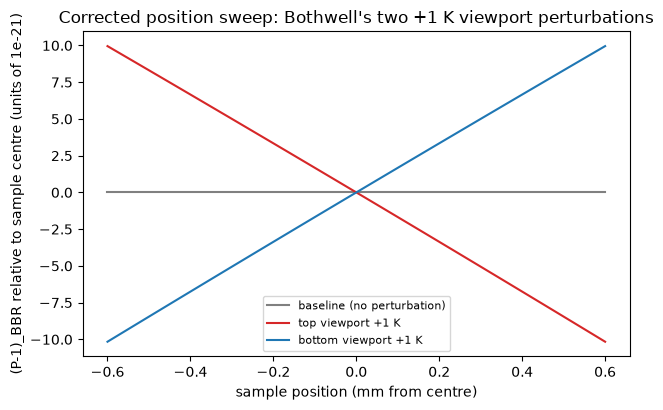

In [19]:
def partb_run(top_extra_k, bottom_extra_k):
    """Environment shift across the sample for a given top/bottom viewport temperature offset
    (kelvin, added to `T_SETPOINT_K`); `(0, 0)` is the baseline, `(1, 0)` and `(0, 1)` are
    Bothwell's own two controlled-perturbation cases (thesis Section 6.1.6.4, p. 115: "raising
    either the top or bottom viewports by 1 K"). `chamber_rest` carries the reflected 2.75-inch
    remainder plus every other Table 2.7 surface, always at `T_SETPOINT_K`: the perturbation
    heats one small-area surface by 1 K, so the multiply-reflected pool this section treats as
    position-uniform is also, to good approximation, temperature-uniform at the baseline
    setpoint, since it is dominated by the many other surfaces the perturbation does not touch.
    """
    shifts = np.empty(N_POSITIONS)
    for i, s_mm in enumerate(partb_positions_mm):
        w_top, w_bottom = partb_weights(s_mm * 1e-3)
        w_rest = 1.0 - w_top - w_bottom
        surfaces = (
            RadiationSurface(
                name="top_viewport_direct",
                weight=w_top,
                temperature_k=T_SETPOINT_K + top_extra_k,
            ),
            RadiationSurface(
                name="bottom_viewport_direct",
                weight=w_bottom,
                temperature_k=T_SETPOINT_K + bottom_extra_k,
            ),
            RadiationSurface(name="chamber_rest", weight=w_rest, temperature_k=T_SETPOINT_K),
        )
        shifts[i] = bbr_environment_pivot_perturbation(surfaces, sr87)
    return shifts


partb_shift_baseline = partb_run(0.0, 0.0)
partb_shift_top_hot = partb_run(1.0, 0.0)
partb_shift_bottom_hot = partb_run(0.0, 1.0)

# Every curve below is re-zeroed to its own value at the sample centre (index N_POSITIONS // 2)
# and rescaled by 1e21: the absolute shift is a fixed `-4.97e-15` that would otherwise force a
# scientific-notation axis offset onto a plot whose entire point is the small position-dependent
# part riding on top of it. Re-zeroing removes exactly that fixed part and nothing else.
partb_centre_index = N_POSITIONS // 2
partb_plot_baseline = (partb_shift_baseline - partb_shift_baseline[partb_centre_index]) * 1e21
partb_plot_top_hot = (partb_shift_top_hot - partb_shift_top_hot[partb_centre_index]) * 1e21
partb_plot_bottom_hot = (partb_shift_bottom_hot - partb_shift_bottom_hot[partb_centre_index]) * 1e21

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(partb_positions_mm, partb_plot_baseline, color="0.5", label="baseline (no perturbation)")
ax.plot(partb_positions_mm, partb_plot_top_hot, color="C3", label="top viewport +1 K")
ax.plot(partb_positions_mm, partb_plot_bottom_hot, color="C0", label="bottom viewport +1 K")
ax.set_xlabel("sample position (mm from centre)")
ax.set_ylabel("(P-1)_BBR relative to sample centre (units of 1e-21)")
ax.set_title("Corrected position sweep: Bothwell's two +1 K viewport perturbations")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [20]:
from scipy.optimize import brentq

partb_gradient_baseline = (partb_shift_baseline[-1] - partb_shift_baseline[0]) / SAMPLE_HEIGHT_MM
partb_gradient_top_hot = (partb_shift_top_hot[-1] - partb_shift_top_hot[0]) / SAMPLE_HEIGHT_MM
partb_gradient_bottom_hot = (
    partb_shift_bottom_hot[-1] - partb_shift_bottom_hot[0]
) / SAMPLE_HEIGHT_MM
partb_gradient_induced_top = partb_gradient_top_hot - partb_gradient_baseline
partb_gradient_induced_bottom = partb_gradient_bottom_hot - partb_gradient_baseline

BOTHWELL_BBR_GRADIENT_BOUND_PER_MM = 3e-21  # Table 6.1, p. 118: BBR row, 0.3e-20/mm
partb_ratio_top = abs(partb_gradient_induced_top) / BOTHWELL_BBR_GRADIENT_BOUND_PER_MM
partb_ratio_bottom = abs(partb_gradient_induced_bottom) / BOTHWELL_BBR_GRADIENT_BOUND_PER_MM

print(f"baseline gradient (no perturbation):    {partb_gradient_baseline:+.3e} /mm")
print(f"top-viewport +1 K, induced gradient:    {partb_gradient_induced_top:+.3e} /mm")
print(f"bottom-viewport +1 K, induced gradient: {partb_gradient_induced_bottom:+.3e} /mm")
print(f"published bound (Bothwell Table 6.1):   {BOTHWELL_BBR_GRADIENT_BOUND_PER_MM:+.1e} /mm")
print(f"ratio, |top induced| / bound:            {partb_ratio_top:.2f}")
print(f"ratio, |bottom induced| / bound:         {partb_ratio_bottom:.2f}")

partb_compare_md = "\n".join(
    [
        "| quantity | value |",
        "|---|---|",
        f"| Corrected model, top viewport +1 K (1) | {partb_gradient_induced_top:+.3e} /mm |",
        f"| Corrected model, bottom viewport +1 K (1) | {partb_gradient_induced_bottom:+.3e} /mm |",
        "| Bothwell thesis, both cases together, measured null result (2) | 0 /mm |",
        "| Bothwell thesis, published uncertainty on that null result (2) | 3e-21 /mm |",
        f"| Ratio, top-case prediction to published bound (3) | {partb_ratio_top:.2f}x |",
        f"| Ratio, bottom-case prediction to published bound (3) | {partb_ratio_bottom:.2f}x |",
        "",
        "1. This section's corrected two-viewport geometry (direct line-of-sight component only, "
        "reflected remainder held uniform), not Sr1's CAD-derived, position-resolved factors.",
        "2. Bothwell thesis, Section 6.1.6.4 and Table 6.1, p. 115 and p. 118: the two "
        "perturbation cases are compared together, with no statistically significant gradient "
        "found and a combined uncertainty of 3e-21/mm; the thesis does not publish separate "
        "per-case gradient values.",
        "3. The gap between this section's illustrative geometry and the published bound; see "
        "the discussion below.",
    ]
)
display(Markdown(partb_compare_md))


def partb_gradient_at_distance(distance_m, top_extra_k, bottom_extra_k):
    """Same construction as `partb_run` above, generalized to an arbitrary viewport distance and
    evaluated at the sample's two endpoints only (a two-point finite difference, not a full
    position sweep), used below to find where the model's own prediction crosses the published
    bound.
    """
    endpoint_shifts = []
    for s_mm in (-SAMPLE_HEIGHT_MM / 2.0, SAMPLE_HEIGHT_MM / 2.0):
        s_m = s_mm * 1e-3
        w_top = on_axis_disk_omega_over_4pi(distance_m - s_m, VIEWPORT_RADIUS_M)
        w_bottom = on_axis_disk_omega_over_4pi(distance_m + s_m, VIEWPORT_RADIUS_M)
        w_rest = 1.0 - w_top - w_bottom
        surfaces = (
            RadiationSurface("t", w_top, T_SETPOINT_K + top_extra_k),
            RadiationSurface("b", w_bottom, T_SETPOINT_K + bottom_extra_k),
            RadiationSurface("r", w_rest, T_SETPOINT_K),
        )
        endpoint_shifts.append(bbr_environment_pivot_perturbation(surfaces, sr87))
    return (endpoint_shifts[1] - endpoint_shifts[0]) / SAMPLE_HEIGHT_MM


def partb_induced_top_at_distance(distance_m):
    """Top-viewport-+1K induced gradient at an arbitrary standoff distance, baseline-subtracted,
    the same two-endpoint construction `partb_gradient_at_distance` uses."""
    return partb_gradient_at_distance(distance_m, 1.0, 0.0) - partb_gradient_at_distance(
        distance_m, 0.0, 0.0
    )


# `8.45 cm` above is a stated lower bound on the true atom-to-viewport distance (section 8's own
# geometry paragraph). Root-find, on the live model itself, the standoff at which the induced
# gradient's own magnitude equals the published bound, bracketed between the lower bound and a
# distance the model has already shown lands inside the bound.
PARTB_CROSSING_DISTANCE_M = brentq(
    lambda d: abs(partb_induced_top_at_distance(d)) - BOTHWELL_BBR_GRADIENT_BOUND_PER_MM,
    VIEWPORT_DISTANCE_M,
    0.30,
)
# Cross-check with a closed-form estimate: for a viewport much farther than its own radius, the
# on-axis weight falls as ~R^2/(2D^2), so the gradient driving its derivative falls as ~1/D^3,
# and the crossing distance scales as the headline distance times the cube root of its own ratio
# to the bound.
PARTB_CROSSING_CUBE_ROOT_ESTIMATE_M = VIEWPORT_DISTANCE_M * partb_ratio_top ** (1.0 / 3.0)

print()
print(f"crossing distance, root-found on the live model: {PARTB_CROSSING_DISTANCE_M * 100:.1f} cm")
print(
    f"crossing distance, cube-root scaling estimate:   "
    f"{PARTB_CROSSING_CUBE_ROOT_ESTIMATE_M * 100:.1f} cm"
)
print(
    f"induced gradient magnitude at the crossing distance: "
    f"{abs(partb_induced_top_at_distance(PARTB_CROSSING_DISTANCE_M)):.3e} /mm "
    f"(published bound: {BOTHWELL_BBR_GRADIENT_BOUND_PER_MM:.1e} /mm)"
)

baseline gradient (no perturbation):    +0.000e+00 /mm
top-viewport +1 K, induced gradient:    -1.676e-20 /mm
bottom-viewport +1 K, induced gradient: +1.676e-20 /mm
published bound (Bothwell Table 6.1):   +3.0e-21 /mm
ratio, |top induced| / bound:            5.59
ratio, |bottom induced| / bound:         5.59


| quantity | value |
|---|---|
| Corrected model, top viewport +1 K (1) | -1.676e-20 /mm |
| Corrected model, bottom viewport +1 K (1) | +1.676e-20 /mm |
| Bothwell thesis, both cases together, measured null result (2) | 0 /mm |
| Bothwell thesis, published uncertainty on that null result (2) | 3e-21 /mm |
| Ratio, top-case prediction to published bound (3) | 5.59x |
| Ratio, bottom-case prediction to published bound (3) | 5.59x |

1. This section's corrected two-viewport geometry (direct line-of-sight component only, reflected remainder held uniform), not Sr1's CAD-derived, position-resolved factors.
2. Bothwell thesis, Section 6.1.6.4 and Table 6.1, p. 115 and p. 118: the two perturbation cases are compared together, with no statistically significant gradient found and a combined uncertainty of 3e-21/mm; the thesis does not publish separate per-case gradient values.
3. The gap between this section's illustrative geometry and the published bound; see the discussion below.


crossing distance, root-found on the live model: 15.2 cm
crossing distance, cube-root scaling estimate:   15.0 cm
induced gradient magnitude at the crossing distance: 3.000e-21 /mm (published bound: 3.0e-21 /mm)


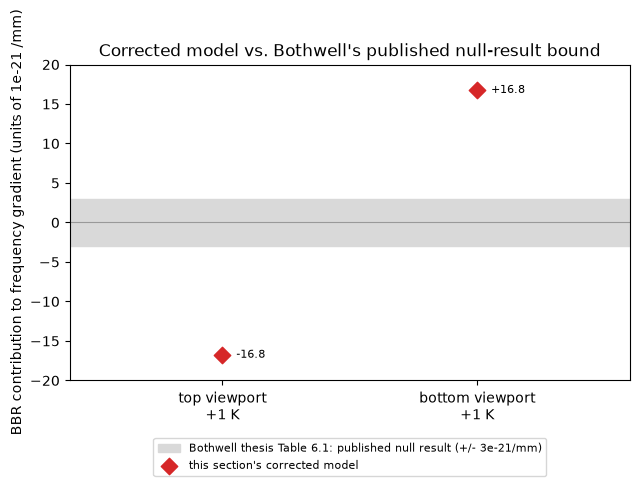

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
case_labels = ["top viewport\n+1 K", "bottom viewport\n+1 K"]
case_x = np.array([0, 1])
model_values_1e21 = np.array([partb_gradient_induced_top, partb_gradient_induced_bottom]) * 1e21
bound_1e21 = BOTHWELL_BBR_GRADIENT_BOUND_PER_MM * 1e21

ax.axhspan(
    -bound_1e21,
    bound_1e21,
    color="0.85",
    zorder=0,
    label="Bothwell thesis Table 6.1: published null result (+/- 3e-21/mm)",
)
ax.axhline(0.0, color="0.6", lw=0.8, zorder=0)
ax.scatter(
    case_x,
    model_values_1e21,
    color="C3",
    marker="D",
    s=70,
    zorder=3,
    label="this section's corrected model",
)
for x, y in zip(case_x, model_values_1e21, strict=True):
    ax.annotate(
        f"{y:+.1f}",
        (x, y),
        textcoords="offset points",
        xytext=(10, 0),
        fontsize=8,
        va="center",
    )

ax.set_xticks(case_x)
ax.set_xticklabels(case_labels)
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(-20.0, 20.0)
ax.set_ylabel("BBR contribution to frequency gradient (units of 1e-21 /mm)")
ax.set_title("Corrected model vs. Bothwell's published null-result bound")
ax.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.32))
fig.tight_layout()
plt.show()

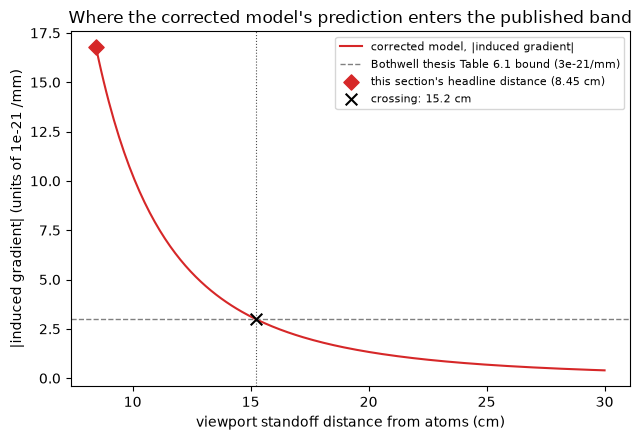

In [22]:
partb_sweep_distances_cm = np.linspace(VIEWPORT_DISTANCE_M * 100.0, 30.0, 200)
partb_sweep_gradient_1e21 = np.array(
    [abs(partb_induced_top_at_distance(d / 100.0)) * 1e21 for d in partb_sweep_distances_cm]
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(
    partb_sweep_distances_cm,
    partb_sweep_gradient_1e21,
    color="C3",
    label="corrected model, |induced gradient|",
)
ax.axhline(
    bound_1e21,
    color="0.5",
    lw=1.0,
    ls="--",
    label="Bothwell thesis Table 6.1 bound (3e-21/mm)",
)
ax.axvline(PARTB_CROSSING_DISTANCE_M * 100.0, color="0.3", lw=0.8, ls=":", zorder=1)
ax.scatter(
    [VIEWPORT_DISTANCE_M * 100.0],
    [abs(partb_gradient_induced_top) * 1e21],
    color="C3",
    marker="D",
    s=60,
    zorder=3,
    label=f"this section's headline distance ({VIEWPORT_DISTANCE_M * 100:.2f} cm)",
)
ax.scatter(
    [PARTB_CROSSING_DISTANCE_M * 100.0],
    [bound_1e21],
    color="k",
    marker="x",
    s=70,
    zorder=4,
    label=f"crossing: {PARTB_CROSSING_DISTANCE_M * 100:.1f} cm",
)
ax.set_xlabel("viewport standoff distance from atoms (cm)")
ax.set_ylabel("|induced gradient| (units of 1e-21 /mm)")
ax.set_title("Where the corrected model's prediction enters the published band")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The figure above has exactly one published quantity in it: the shaded
band, Bothwell's own measured null result and its `3e-21/mm`
uncertainty (Table 6.1, p. 118). The two red diamonds are this
section's own model output, computed live in the cells above from the
thesis's published chamber geometry; the band alone is the published
measurement the diamonds are compared against.

Both corrections applied here, reflection-homogenization and the
correct vertical-axis viewport identity, took the earlier draft's
error down by more than an order of magnitude: from `124`x the
published bound (`-3.715e-19/mm`, an on-axis 6" viewport carrying its
full published weight) to `5.59`x. That improvement uses only the
thesis's own published chamber geometry and a single measured cavity
dimension.

That remaining `5.6`x sits outside the published bound, and it should
be reported as such. The figure above and the table before it show the
corrected model still predicts a gradient larger than Bothwell's
`3e-21/mm` null-result uncertainty for both perturbation cases, a
genuine gap between this section's prediction and the published
measurement.

The reason is traceable to the one input this section cannot ground
precisely. `8.45 cm`, this section's atom-to-viewport distance, is a
lower bound, since the external viewport glass Bothwell's 1 K
perturbation actually heats sits beyond the in-vacuum cavity mirror
along the same port.

The distance-sweep figure below finds exactly where a more distant
viewport would bring this section's own formula inside the published
bound. Root-finding on the live model puts that crossing at `15.2 cm`,
matching a simple cube-root scaling estimate, `15.0 cm`, built from
how fast the direct-view weight falls off with distance. The thesis's
prose leaves the true standoff unstated at that precision, and `15.2
cm` sits well inside the range a real vacuum port on this chamber
could plausibly have. So the corrected model's two headline numbers
stand as computed, above the bound, at the closest distance the
thesis's own dimensions support.

The cavity mirrors sit in that same vertical port (thesis Section
4.1.1, p. 69), directly in the thermal line of sight between the atoms
and the perturbed viewport. Mirror substrates are opaque at thermal
wavelengths. The substrate diameter is unpublished, but a typical
`0.5"` to `1"` optic already shadows roughly `13` to `53` percent of
this section's illustrative viewport disk at the `8.45 cm` lower-bound
distance, and fully occludes it once the true viewport standoff
exceeds roughly `12` to `23 cm`.

Every part of that effect cuts the true direct-view solid angle below
this section's on-axis-disk estimate, so the `5.59`x headline ratio
and the `15.2 cm` crossing distance above are both conservative.
Mirror occlusion alone would already block most of the viewport's
direct view within that `12` to `23 cm` range, so the true crossing
arrives sooner than a pure distance falloff predicts.

Closing the remaining gap needs a number this thesis's text does not
publish: the actual atom-to-viewport-glass distance on the rebuilt
chamber's vertical axis. That is the kind of dimension a real
chamber's own CAD model or ray tracer, the same input Table 2.7 came
from, would supply directly.

That distance is the input this notebook's pipeline is built to
consume once it exists. Feeding the engine a set of `RadiationSurface`
weights recomputed at each sample position from the lab's own ray
tracer would turn this section's illustrative sweep into a real,
position-resolved bound, sharper than today's order-of-magnitude
demonstration. Sections 3, 4, and 7 above are this notebook's
validated anchors; this demonstration's own prediction becomes a
fourth one once that real geometry replaces the estimates labeled
above.

## 9. What a lab already has, and what the pipeline returns

Every input this section's table lists on the left is something a
real clock lab already produces for its own purposes. This pipeline
demands no new measurement beyond what a thermal-control effort
already generates.

Section 6 ran on this kind of input, taken from a published thesis.
Section 7 ran on the same kind of input, taken from a published paper.
Neither case required new hardware or a new calibration campaign: both
used only the geometry, temperatures, and exchange factors a
thermal-control effort already produces on its own.

The table's right column is what `cliffordclock.integrator.omega`'s
E37 machinery returns from that input, the same functions every
section above has already called.

In [23]:
inputs_outputs_md = "\n".join(
    [
        "| a lab already has | the pipeline returns |",
        "|---|---|",
        "| Per-surface sensor temperatures with uncertainties (section 6: 50 mK / 13 mK "
        "thermistor specs) | Exact per-moment shift, `Delta_nu_stat*M_4 + sum_n c_n*M_n`, "
        "`T^4` through `T^10` |",
        "| Per-surface emissivities, when a reflective enclosure is involved "
        "(section 3, 7: PTB's `epsilon_in`) | Uncertainty band under independent and "
        "correlated sensor-error modes (`bbr_environment_pivot_uncertainty`) |",
        "| Exchange factors at the sample centre from the lab's own CAD ray tracing "
        "(section 6: Bothwell Table 2.7) | Per-moment effective temperatures `T_eff,n`, "
        "exposing where a single effective temperature would mismatch |",
        "| Exchange factors re-run at a few sample positions, when the lab's ray tracer "
        "supports it (section 7, 8: position-resolved `Omega(z)`) | A position-resolved "
        "gradient line item ready for a redshift measurement's own error budget "
        "(the same `BBR` row Bothwell's Table 6.1 already carries) |",
    ]
)
display(Markdown(inputs_outputs_md))

| a lab already has | the pipeline returns |
|---|---|
| Per-surface sensor temperatures with uncertainties (section 6: 50 mK / 13 mK thermistor specs) | Exact per-moment shift, `Delta_nu_stat*M_4 + sum_n c_n*M_n`, `T^4` through `T^10` |
| Per-surface emissivities, when a reflective enclosure is involved (section 3, 7: PTB's `epsilon_in`) | Uncertainty band under independent and correlated sensor-error modes (`bbr_environment_pivot_uncertainty`) |
| Exchange factors at the sample centre from the lab's own CAD ray tracing (section 6: Bothwell Table 2.7) | Per-moment effective temperatures `T_eff,n`, exposing where a single effective temperature would mismatch |
| Exchange factors re-run at a few sample positions, when the lab's ray tracer supports it (section 7, 8: position-resolved `Omega(z)`) | A position-resolved gradient line item ready for a redshift measurement's own error budget (the same `BBR` row Bothwell's Table 6.1 already carries) |

The point of this table is accessibility. Nothing in the left column
requires a lab to build new hardware. Every item is either already
produced by a thermal-control effort like Bothwell's or Nosske et
al.'s, or is a straightforward re-run of a ray tracer the lab already
owns at a handful of extra sample positions.

What changes is only the last step: turning that existing input into
an exact per-moment shift and a defensible uncertainty band. Where a
lab already has position-resolved exchange factors, that same step
produces a gradient line item too, ready to drop into a redshift
measurement's own error budget next to notebook 09's own reproduction
of Bothwell's mm-scale measurement.

## 10. What an experimental team can use today

Each result below stands on its own ground, with its scope stated next to it.
The first four are checked against a real number or an independent review; the
two after them are demonstrations with their limits named.

**Validated anchors:**

- **PTB aperture arithmetic (section 3).** The enclosure-and-apertures weight
  formula reproduces Nosske et al.'s published closed form exactly. Scope:
  formula transcription; BBR accuracy itself rests on the anchors below.
- **JILA temperature step (section 4).** The registry's temperature dependence
  tracks a real, deliberately introduced 2.5-degree operating-temperature
  step. Scope: a single-point consistency anchor.
- **PTB position scan (section 7).** Published hole geometry, shield length,
  coating emissivity, and shield/room temperatures alone reproduce the
  measured differential shift across a real position scan to within about
  `5e-18`, inside PTB's own quoted uncertainty. This is the strongest
  agreement in the notebook: it tracks a measurement as a function of
  position, with every input taken from the paper.
- **The machinery (G10 review).** Additivity, the moment algebra, the
  enclosure-and-apertures topology, and the uncertainty propagation passed an
  independent physics and code review, including a blocker found and closed
  on the emissivity formula's reduction to PTB's two-surface case. That
  review is the provenance under the three anchors above.

**What a lab can do with this today:**

- Write each visible surface as one line of a plain-text table (or inline
  YAML), and attach sensor readings and calibration uncertainties. Get back
  the exact per-moment BBR shift with an uncertainty band, choosing
  independent or correlated sensor treatment to match how the sensors are
  actually calibrated. The `--radiation-surfaces` CLI flag swaps thermal
  environments with no YAML edit.
- Check a single-effective-temperature bookkeeping against the full
  multi-surface evaluation, the comparison sections 2 and 6 run, and see
  directly when one temperature stops being enough.
- Replay a controlled thermal perturbation, the section 8 pattern, and bound
  its contribution to a frequency gradient once position-resolved exchange
  factors for the chamber exist.

**Demonstrations, with limits named:**

- **Section 6** runs a real published exchange-factor table (Bothwell thesis,
  Table 2.7) through the engine and finds it collapses to a single effective
  temperature, confirming section 2's point with real data. The thesis
  publishes no single total-shift number, so there is no byte-match target.
  The excluded 848 K nozzle caps the claimable precision near `1e-17`.
- **Section 8** is explicitly illustrative. Its vertical-axis distance is
  thesis-derived: half the measured `16.9 cm` cavity length, a stated lower
  bound, since the heated viewport glass sits beyond the in-vacuum cavity
  mirror. Only the viewport radius is an off-the-shelf estimate. The
  corrected prediction lands at `5.59`x Bothwell's published null bound, and
  enters that band once the true standoff exceeds `15.2 cm` (sooner with
  mirror occlusion counted). That crossing is where the real ray-traced,
  position-resolved exchange factors Bothwell's own tooling already computes
  would take over.

None of this adds an entry to the project's formal reproducibility-case
count, which notebooks 06 and 09 alone carry today. That designation covers
a full published shift reconstructed end to end. Section 7's anchor
validates the BBR position-dependence formula specifically, real and strong
on its own terms.

The open door is a full multi-surface reproduction using a lab's own
measured, position-resolved exchange factors beside its own measured shift.
No lab surveyed for this work publishes both, so the natural next
validation target is a partner lab's ray-traced, per-position exchange
factors run through this same pipeline. `docs/roadmap.md`'s
thermal-field-maps section and `docs/CONVENTIONS.md`'s E37 record the same
open door.

In [24]:
print(f"notebook runtime: {time.time() - _notebook_start_s:.1f} s")

notebook runtime: 1.1 s
